In [302]:
# Imports and Utility Functions - Adapted from SDXL-turbo example for FLUX
from autoencoder import TopkSparseAutoencoder
import torch
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from PIL import Image
from diffusers import FluxPipeline
from einops import rearrange
import re
from pathlib import Path
import sys

# For Text Stream visualization
try:
    from scipy.ndimage import zoom
    has_scipy = True
except ImportError:
    has_scipy = False
    print("⚠️  scipy not available - cross-attention heatmaps will use simple upsampling")

# Add scripts directory to path
sys.path.append('./scripts')
from flux_sae_utils import replace_with_feature, add_feature_on_area, plot_image_heatmap


In [303]:
# Load FLUX Pipeline and SAEs
dtype = torch.bfloat16
FLUX_MODEL = "black-forest-labs/FLUX.1-schnell"

# Load pipeline
pipe = FluxPipeline.from_pretrained(
    FLUX_MODEL,
    torch_dtype=dtype,
    device_map="balanced" if torch.cuda.device_count() > 1 else None
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

print(f"✅ Loaded FLUX pipeline: {FLUX_MODEL}")

# ===== SAE LOADING CONFIGURATION =====
# Pointer-style: Specify which SAEs to load using indices 0-5
# 0 = transformer_blocks.0.0 (MMDiT Layer 0, Query, image stream)
# 1 = transformer_blocks.0.1 (MMDiT Layer 0, Key, text stream)
# 2 = transformer_blocks.9.0 (MMDiT Layer 9, Query, image stream)
# 3 = transformer_blocks.9.1 (MMDiT Layer 9, Key, text stream)
# 4 = single_transformer_blocks.9 (DiT Layer 9)
# 5 = single_transformer_blocks.37 (DiT Layer 37)

sae_indices_to_load = [5]  # Change this list to load different SAEs, e.g., [0, 1, 2] or [0, 5]

# All 6 SAE configurations (ordered list, index 0-5)
all_sae_configs = [
    {
        "code": "transformer_blocks.0.0",
        "block": "transformer_blocks.0.attn",
        "sae_model": "RE-N-Y/cc3m-transformer_blocks.0-0",
        "stream": 0,
        "mean_path": None,
        "description": "MMDiT Layer 0, Image Stream (32×32 spatial)"
    },
    {
        "code": "transformer_blocks.0.1",
        "block": "transformer_blocks.0.attn",
        "sae_model": "RE-N-Y/cc3m-transformer_blocks.0-1",
        "stream": 1,
        "mean_path": None,
        "description": "MMDiT Layer 0, Text Stream (512 tokens, NOT spatial)"
    },
    {
        "code": "transformer_blocks.9.0",
        "block": "transformer_blocks.9.attn",
        "sae_model": "RE-N-Y/cc3m-transformer_blocks.18-0",  # Note: model uses 18, we hook at 9
        "stream": 0,
        "mean_path": None,
        "description": "MMDiT Layer 9, Image Stream (32×32 spatial)"
    },
    {
        "code": "transformer_blocks.9.1",
        "block": "transformer_blocks.9.attn",
        "sae_model": "RE-N-Y/cc3m-transformer_blocks.18-1",
        "stream": 1,
        "mean_path": None,
        "description": "MMDiT Layer 9, Text Stream (512 tokens, NOT spatial)"
    },
    {
        "code": "single_transformer_blocks.9",
        "block": "single_transformer_blocks.9.attn",
        "sae_model": "RE-N-Y/cc3m-single_transformer_blocks.9",
        "stream": 0,
        "mean_path": None,
        "description": "DiT Layer 9"
    },
    {
        "code": "single_transformer_blocks.37",
        "block": "single_transformer_blocks.37.attn",
        "sae_model": "RE-N-Y/cc3m-single_transformer_blocks.37",
        "stream": 0,
        "mean_path": None,
        "description": "DiT Layer 37"
    },
]

# Build code_to_block mapping and filter configs based on indices
code_to_block = {}
saes_dict = {}
means_dict = {}
streams_dict = {}

print(f"Loading SAEs at indices: {sae_indices_to_load} (out of {len(all_sae_configs)} available)\n")

for idx in sae_indices_to_load:
    if idx < 0 or idx >= len(all_sae_configs):
        print(f"⚠️  Skipping invalid index {idx} (must be 0-{len(all_sae_configs)-1})")
        continue
    
    config = all_sae_configs[idx]
    code = config["code"]
    
    print(f"[{idx}] Loading: {config['description']}")
    print(f"     Code: {code}, Model: {config['sae_model']}")

    try:
        # Add to code_to_block mapping
        code_to_block[code] = config["block"]
        
        # Load SAE
        sae = TopkSparseAutoencoder.from_pretrained(config["sae_model"])
        sae = sae.to('cuda', dtype=dtype)
        sae.eval()
        
        saes_dict[code] = sae
        streams_dict[code] = config["stream"]
        
        # Compute means (use bias or zeros)
        if config["mean_path"] and os.path.exists(config["mean_path"]):
            means = torch.load(config["mean_path"], weights_only=True)
            means = means.to('cuda', dtype=dtype)
        else:
            if hasattr(sae, 'bias') and sae.bias is not None:
                means = sae.bias.clone()
            else:
                means = torch.zeros(sae.pages, device='cuda', dtype=dtype)
        
        means_dict[code] = means
        
        print(f"     ✅ Successfully loaded")
        print(f"     Features: {sae.features}, Pages: {sae.pages}, k: {sae.k}\n")
    except Exception as e:
        print(f"     ❌ Failed to load: {str(e)}\n")

print(f"✅ Successfully loaded {len(saes_dict)} SAE(s)")
if len(saes_dict) == 0:
    print("⚠️  Warning: No SAEs loaded! Check sae_indices_to_load and specify at least one index (0-5).")

# Use first SAE for analysis
first_code = list(saes_dict.keys())[0]
first_sae = saes_dict[first_code]
first_block = code_to_block[first_code]
first_stream = streams_dict[first_code]


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Loaded FLUX pipeline: black-forest-labs/FLUX.1-schnell
Loading SAEs at indices: [5] (out of 6 available)

[5] Loading: DiT Layer 37
     Code: single_transformer_blocks.37, Model: RE-N-Y/cc3m-single_transformer_blocks.37
     ✅ Successfully loaded
     Features: 3072, Pages: 49152, k: 16

✅ Successfully loaded 1 SAE(s)


Generating original image with prompt: 'a woman with pink hair standing in a forest, holding a sign that says 'SAE test''
✅ Original image generated


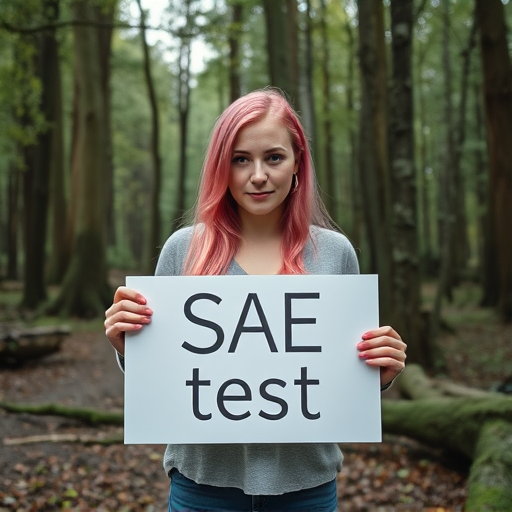

In [304]:
# Generate original image with prompt
# prompt = "A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party."
prompt = "a woman with pink hair standing in a forest, holding a sign that says 'SAE test'"

print(f"Generating original image with prompt: '{prompt}'")
test_width = 512
test_height = 512

original_output = pipe(
    prompt=prompt,
    height=test_height,
    width=test_width,
    num_inference_steps=4,
    guidance_scale=3.5,
    generator=torch.Generator(device="cuda").manual_seed(42)
)

original_image = original_output.images[0]
print("✅ Original image generated")
original_image

In [305]:
# generate_sparse_maps function - Adapted from SDXL-turbo for FLUX
# For FLUX, we capture activations using hooks and compute difference

# Global storage for DiT text sparse_maps (for DiT layers with concatenated streams)
_dit_text_sparse_maps_storage = {}

def calculate_spatial_dims_from_tokens(num_tokens):
    """
    Calculate spatial grid dimensions (h, w) from number of image tokens.
    
    FLUX reduces image dimensions by factor of 16:
    - VAE: downsamples by 8
    - Patchify: groups by 2
    - Total: 8×2 = 16
    
    For an M×N image:
    - Grid width: M/16
    - Grid height: N/16
    - Total tokens: (M×N)/256
    
    This function finds the grid dimensions by factoring the token count.
    
    Args:
        num_tokens: Number of image tokens (e.g., 1024 for 512×512, 4096 for 1024×1024)
    
    Returns:
        (h, w): Spatial grid dimensions, or None if can't be factored
    """
    # Try to find factors that represent a reasonable spatial grid
    # Common resolutions and their token counts:
    # 512×512 → 32×32 = 1024 tokens
    # 768×768 → 48×48 = 2304 tokens
    # 1024×1024 → 64×64 = 4096 tokens
    # 1280×1280 → 80×80 = 6400 tokens
    # 1536×1536 → 96×96 = 9216 tokens
    
    # Find all factor pairs
    possible_dims = []
    max_dim = int(np.sqrt(num_tokens)) + 1
    
    for h in range(8, min(max_dim + 1, 256)):  # Reasonable grid sizes: 8 to 256
        w = num_tokens // h
        if h * w == num_tokens and w <= 256:
            possible_dims.append((h, w))
    
    if possible_dims:
        # Prefer square-like dimensions (closest to square)
        h, w = min(possible_dims, key=lambda x: abs(x[0] - x[1]))
        return h, w
    else:
        return None

def generate_sparse_maps(code, prompt, num_steps=1):
    """
    Generate sparse activation maps for a given prompt.
    Adapted from SDXL-turbo's generate_sparse_maps for FLUX.
    
    Args:
        code: Layer code (e.g., "transformer_blocks.0.0")
        prompt: Text prompt
        num_steps: Number of inference steps (use 1 for faster computation)
    
    Returns:
        sparse_maps: Sparse activation maps (height, width, num_features) or (tokens, num_features)
        input_activations: Input activations (for reference)
        output_activations: Output activations (for reference)
    
    Note: For DiT layers, text token sparse_maps are stored in _dit_text_sparse_maps_storage[code]
    """
    block = code_to_block[code]
    sae = saes_dict[code]
    stream = streams_dict[code]
    
    # Storage for activations
    input_activations = None
    output_activations = None
    
    def input_hook(module, input):
        nonlocal input_activations
        # Pre-hook: input is a tuple of arguments
        # For FLUX attention, the first argument is typically hidden_states
        try:
            if isinstance(input, tuple):
                if len(input) > 0:
                    # For attention modules, input[0] is hidden_states
                    act = input[0]
                else:
                    # Empty tuple, skip
                    return
            else:
                # Not a tuple, use directly
                act = input
            
            # Store the input activation (this is what goes into the attention module)
            # For attention, we'll capture the output which has query/key
            # So we store the input hidden_states here
            input_activations = act
        except Exception as e:
            # If we can't capture input, that's okay - we'll use output only
            pass
    
    def output_hook(module, input, output):
        nonlocal output_activations
        if isinstance(output, tuple):
            query, key = output
            output_activations = query if stream == 0 else key
        else:
            output_activations = output
        return output
    
    # Register hooks
    input_handle = pipe.transformer.get_submodule(block).register_forward_pre_hook(input_hook)
    output_handle = pipe.transformer.get_submodule(block).register_forward_hook(output_hook)
    
    try:
        # Generate to capture activations
        _ = pipe(
            prompt=prompt,
            height=test_height,
            width=test_width,
            num_inference_steps=num_steps,
            guidance_scale=3.5 if num_steps > 1 else 0.0,
            generator=torch.Generator(device="cuda").manual_seed(42)
        )
        
        # For FLUX, we use output_activations directly (query/key after projection)
        # The SAE was trained on these activations, so we encode them directly
        # Similar to SDXL-turbo's approach but using output instead of diff
        if output_activations is not None:
            # Reshape to spatial dimensions
            # FLUX activations: (batch, seq, height, width, dim)
            if len(output_activations.shape) == 5:
                batch, seq, h, w, dim = output_activations.shape
                # Use output activations directly (SAE was trained on these)
                act = output_activations.permute(0, 1, 3, 4, 2).squeeze(0).squeeze(0)  # (h, w, dim)
            elif len(output_activations.shape) == 4:
                # Handle different shapes
                if output_activations.shape[-1] == sae.features:
                    # Assume (batch, height, width, dim)
                    act = output_activations.squeeze(0)  # (h, w, dim)
                else:
                    # Flatten and process
                    act_flat = rearrange(output_activations, "b ... d -> (b ...) d")
                    # Encode flattened
                    with torch.no_grad():
                        sparse_maps_flat = sae.encode(act_flat)
                    return sparse_maps_flat, input_activations, output_activations
            elif len(output_activations.shape) == 3:
                # 3D case: (batch, seq_length, dim)
                batch, seq_length, dim = output_activations.shape
                
                # FLUX Schnell architecture knowledge:
                # - MMDiT layers (transformer_blocks): Image stream only = 1024 tokens = 32×32 spatial grid
                # - DiT layers (single_transformer_blocks): Fused stream = 1024 image + 512 text = 1536 tokens
                #   - Sequence is concatenated: [Image_Tokens (1024), Text_Tokens (512)]
                #   - For spatial mapping, extract first 1024 tokens (image tokens) and reshape to 32×32
                # - For 512×512 images: VAE latent is 64×64, patches are 2×2 → 32×32 grid
                
                # Check if this is MMDiT (transformer_blocks) or DiT (single_transformer_blocks)
                is_mmdit_layer = code.startswith("transformer_blocks")
                is_dit_layer = code.startswith("single_transformer_blocks")
                
                if is_mmdit_layer:
                    # MMDiT: Double Stream Architecture
                    # The tuple output is (image_stream, text_stream)
                    # - stream=0 (index 0): Image Stream = 1024 tokens (32×32 spatial grid)
                    # - stream=1 (index 1): Text Stream = 512 tokens (T5 text embeddings, NOT spatial)
                    
                    if stream == 1:
                        # Text Stream: sequence-based, NOT spatial
                        # 512 tokens = T5 text embeddings (padded to 512 for compatibility)
                        print(f"   ⚠️  MMDiT Text Stream detected (stream=1)")
                        print(f"   📝 Sequence length {seq_length} = T5 text embeddings (NOT spatial)")
                        print(f"   ⚠️  Text stream is sequence-based - cannot create spatial heatmaps")
                        print(f"   💡 For spatial visualization, use Image Stream (stream=0) instead")
                        # Keep as sequence - don't try to reshape to spatial
                        act_flat = rearrange(output_activations, "b s d -> (b s) d")
                        with torch.no_grad():
                            sparse_maps_flat = sae.encode(act_flat)
                        return sparse_maps_flat, input_activations, output_activations
                    else:
                        # Image Stream (stream=0): Calculate spatial dimensions dynamically
                        # FLUX reduces by factor of 16: for M×N image → (M/16)×(N/16) grid
                        # Common: 512×512 → 32×32 = 1024 tokens, 1024×1024 → 64×64 = 4096 tokens
                        spatial_dims = calculate_spatial_dims_from_tokens(seq_length)
                        
                        if spatial_dims:
                            h, w = spatial_dims
                            print(f"   ✅ MMDiT Image Stream: sequence length {seq_length} = {h}×{w} spatial grid")
                            if seq_length == 1024:
                                print(f"      (512×512 image → 32×32 grid)")
                            elif seq_length == 4096:
                                print(f"      (1024×1024 image → 64×64 grid)")
                            else:
                                print(f"      (Image resolution: {h*16}×{w*16} pixels)")
                            act = output_activations.squeeze(0).reshape(h, w, dim)  # (h, w, dim)
                        else:
                            # Can't infer spatial dimensions, keep as sequence
                            print(f"   ⚠️  MMDiT Image Stream: sequence length {seq_length} cannot be factored into spatial grid")
                            print(f"   💡 Keeping as sequence-based (no spatial reshaping)")
                            act_flat = rearrange(output_activations, "b s d -> (b s) d")
                            with torch.no_grad():
                                sparse_maps_flat = sae.encode(act_flat)
                            return sparse_maps_flat, input_activations, output_activations
                elif is_dit_layer:
                    # DiT: Fused stream = 1024 image + 512 text = 1536 tokens
                    # Sequence is concatenated: [Image_Tokens (0-1023), Text_Tokens (1024-1535)]
                    # IMPORTANT: The SAE was trained on the FULL concatenated sequence (1536 tokens)
                    # So we need to encode the full sequence, then separate image/text sparse_maps
                    
                    # DiT Fused Stream: [Image_Tokens (T_img), Text_Tokens (512)]
                    # Text tokens are always 512, but image tokens vary with resolution
                    num_image_tokens = seq_length - 512  # Extract image token count
                    
                    if num_image_tokens > 0:
                        print(f"   ✅ DiT Fused Stream: sequence length {seq_length} = {num_image_tokens} image + 512 text tokens")
                        print(f"   📝 Sequence structure: [tokens 0-{num_image_tokens-1}: image, tokens {num_image_tokens}-{seq_length-1}: text]")
                        print(f"   💡 SAE was trained on full {seq_length}-token sequence - encoding all tokens")
                        
                        # Encode the FULL sequence (both image and text tokens)
                        # The SAE was trained on this concatenated structure
                        act_full = output_activations.squeeze(0)  # (seq_length, dim)
                        act_flat_full = rearrange(act_full, "s d -> (s) d")
                        
                        with torch.no_grad():
                            sparse_maps_full_flat = sae.encode(act_flat_full)  # (seq_length, features)
                        
                        # Separate into image and text sparse_maps
                        image_sparse_flat = sparse_maps_full_flat[:num_image_tokens, :]  # (num_image_tokens, features)
                        text_sparse_flat = sparse_maps_full_flat[num_image_tokens:, :]    # (512, features)
                        
                        # Calculate spatial dimensions dynamically from image token count
                        spatial_dims = calculate_spatial_dims_from_tokens(num_image_tokens)
                        if spatial_dims:
                            h, w = spatial_dims
                            print(f"   💡 Image tokens: {num_image_tokens} → {h}×{w} spatial grid")
                            if num_image_tokens == 1024:
                                print(f"      (512×512 image → 32×32 grid)")
                            elif num_image_tokens == 4096:
                                print(f"      (1024×1024 image → 64×64 grid)")
                            else:
                                print(f"      (Image resolution: {h*16}×{w*16} pixels)")
                            sparse_maps_image = rearrange(image_sparse_flat, "(h w) f -> h w f", h=h, w=w)
                        else:
                            # Can't reshape to spatial, keep as sequence
                            print(f"   ⚠️  Cannot factor {num_image_tokens} image tokens into spatial grid")
                            print(f"   💡 Keeping image tokens as sequence-based")
                            sparse_maps_image = image_sparse_flat  # Keep as 2D
                        
                        print(f"   ✅ Created separate sparse_maps:")
                        print(f"      - Image tokens (0-1023): {sparse_maps_image.shape}")
                        print(f"      - Text tokens (1024-1535): {text_sparse_flat.shape}")
                        print(f"   💡 Returning image sparse_maps for spatial visualization")
                        print(f"   💡 Text sparse_maps stored in '_dit_text_sparse_maps_storage' dict")
                        
                        # Store text sparse_maps in global storage dict
                        _dit_text_sparse_maps_storage[code] = text_sparse_flat
                        
                        return sparse_maps_image, input_activations, output_activations
                    else:
                        # Sequence length doesn't match expected pattern
                        # Try to infer: assume last 512 tokens are text, rest are image
                        num_image_tokens = seq_length - 512
                        if num_image_tokens > 0:
                            print(f"   ⚠️  DiT Fused Stream: sequence length {seq_length} (unexpected)")
                            print(f"   💡 Assuming {num_image_tokens} image tokens + 512 text tokens")
                            print(f"   💡 Encoding full sequence, then separating image/text tokens")
                            
                            act_full = output_activations.squeeze(0)  # (seq_length, dim)
                            act_flat_full = rearrange(act_full, "s d -> (s) d")
                            
                            with torch.no_grad():
                                sparse_maps_full_flat = sae.encode(act_flat_full)  # (seq_length, features)
                            
                            image_sparse_flat = sparse_maps_full_flat[:num_image_tokens, :]
                            text_sparse_flat = sparse_maps_full_flat[num_image_tokens:, :]
                            
                            # Calculate spatial dimensions dynamically
                            spatial_dims = calculate_spatial_dims_from_tokens(num_image_tokens)
                            if spatial_dims:
                                h, w = spatial_dims
                                sparse_maps_image = rearrange(image_sparse_flat, "(h w) f -> h w f", h=h, w=w)
                            else:
                                sparse_maps_image = image_sparse_flat  # Keep as 2D
                            
                            _dit_text_sparse_maps_storage[code] = text_sparse_flat
                            
                            return sparse_maps_image, input_activations, output_activations
                        else:
                            # Can't determine structure (num_image_tokens <= 0)
                            # This shouldn't happen for valid DiT layers, but handle gracefully
                            print(f"   ⚠️  DiT Fused Stream: sequence length {seq_length} < 512 (unexpected)")
                            print(f"   💡 Cannot determine image/text split - keeping as sequence")
                            act_flat = rearrange(output_activations, "b s d -> (b s) d")
                            with torch.no_grad():
                                sparse_maps_flat = sae.encode(act_flat)
                            return sparse_maps_flat, input_activations, output_activations
                else:
                    # Unknown layer type, try to infer
                    possible_spatial_dims = []
                    max_dim = int(np.sqrt(seq_length)) + 1
                    for h in range(8, min(max_dim + 1, 128)):
                        w = seq_length // h
                        if h * w == seq_length and w <= 128:
                            possible_spatial_dims.append((h, w))
                    
                    if possible_spatial_dims:
                        h, w = min(possible_spatial_dims, key=lambda x: abs(x[0] - x[1]))
                        print(f"   💡 Inferred spatial dimensions: ({h}, {w}) from sequence length {seq_length}")
                        act = output_activations.squeeze(0).reshape(h, w, dim)  # (h, w, dim)
                    else:
                        # Can't infer spatial dimensions, flatten and process
                        act_flat = rearrange(output_activations, "b s d -> (b s) d")
                        # Encode flattened
                        with torch.no_grad():
                            sparse_maps_flat = sae.encode(act_flat)
                        return sparse_maps_flat, input_activations, output_activations
            else:
                # Flatten and process
                act_flat = rearrange(output_activations, "b ... d -> (b ...) d")
                # Encode flattened
                with torch.no_grad():
                    sparse_maps_flat = sae.encode(act_flat)
                return sparse_maps_flat, input_activations, output_activations
            
            # Encode with SAE
            if len(act.shape) == 3:
                # Spatial shape (h, w, dim)
                h, w, dim = act.shape
                act_flat = rearrange(act, "h w d -> (h w) d")
                with torch.no_grad():
                    sparse_maps_flat = sae.encode(act_flat)
                # Reshape back to spatial
                sparse_maps = rearrange(sparse_maps_flat, "(h w) f -> h w f", h=h, w=w)
                return sparse_maps, input_activations, output_activations
            else:
                # Already flattened or different shape
                with torch.no_grad():
                    sparse_maps_flat = sae.encode(act)
                return sparse_maps_flat, input_activations, output_activations
        else:
            raise ValueError("Failed to capture output activations")
    finally:
        input_handle.remove()
        output_handle.remove()

print("✅ generate_sparse_maps function defined")


✅ generate_sparse_maps function defined


In [ ]:
import math
from einops import rearrange
import numpy as np

# ... [Your existing setup code] ...

# Get sparse_maps and top_features with first SAE
print(f"Generating sparse maps for code: {first_code}")
print(f"Using prompt: '{prompt}'")
sparse_maps, input_acts, output_acts = generate_sparse_maps(first_code, prompt, num_steps=1)

# Initialize storage for DiT text maps if not present
dit_text_sparse_maps = None

# --- DIAGNOSTICS ---
print(f"\n🔍 Activation Shape Analysis:")
print(f"   SAE Code: {first_code}")
print(f"   Output activations shape: {output_acts.shape if output_acts is not None else 'None'}")
print(f"   Sparse maps shape (Initial): {sparse_maps.shape}")

# Identify Layer Type
is_mmdit = first_code.startswith("transformer_blocks")
is_dit = first_code.startswith("single_transformer_blocks")

# --- LOGIC TO HANDLE RESHAPING AND SPLITTING ---
print(f"\n💡 Processing Dimensions:")

if output_acts is not None and len(output_acts.shape) == 3:
    batch, total_seq_len, dim = output_acts.shape
    
    # ---------------------------
    # CASE A: DiT (Fused Stream)
    # ---------------------------
    if is_dit:
        print(f"   - Model Type: DiT (Fused Stream)")
        
        # Hardcoded Flux Constants
        TEXT_TOKEN_COUNT = 512 
        
        # Check current shape to decide strategy
        if len(sparse_maps.shape) == 3:
            # IT IS ALREADY SPATIAL (H, W, D)
            # This matches your error state: torch.Size([32, 32, 49152])
            h, w, _ = sparse_maps.shape
            print(f"   - ✅ Input is already a Spatial Grid: ({h}, {w})")
            print(f"   - ℹ️  Text tokens were already separated upstream by generate_sparse_maps")
            
            # IMPORTANT: Check if generate_sparse_maps already stored text sparse_maps
            if first_code in _dit_text_sparse_maps_storage:
                dit_text_sparse_maps = _dit_text_sparse_maps_storage[first_code]
                print(f"   - ✅ Retrieved DiT text sparse_maps from storage: {dit_text_sparse_maps.shape}")
                print(f"   - 💡 Text tokens (512) are available for separate analysis")
            else:
                print(f"   - ⚠️  DiT text sparse_maps not found in storage")
                print(f"   - 💡 This may happen if generate_sparse_maps didn't separate text tokens")
                dit_text_sparse_maps = None
            
        elif len(sparse_maps.shape) == 2:
            # IT IS A FLAT SEQUENCE (Seq, D)
            # This is what the previous code expected
            total_seq_len_in_map = sparse_maps.shape[0]
            
            # Scenario 1: It includes Text (1536 tokens)
            if total_seq_len_in_map > 1024:
                img_token_count = total_seq_len_in_map - TEXT_TOKEN_COUNT
                print(f"   - Splitting Sequence: {total_seq_len_in_map} Total -> {img_token_count} Image + {TEXT_TOKEN_COUNT} Text")
                
                # Split
                img_sparse_maps = sparse_maps[:img_token_count]
                dit_text_sparse_maps = sparse_maps[img_token_count:]
                
                # Store Text
                if '_dit_text_sparse_maps_storage' in globals():
                    _dit_text_sparse_maps_storage[first_code] = dit_text_sparse_maps
                
                # Reshape Image
                grid_side = int(math.sqrt(img_token_count))
                if grid_side * grid_side == img_token_count:
                    sparse_maps = rearrange(img_sparse_maps, "(h w) f -> h w f", h=grid_side, w=grid_side)
                    print(f"   - ✅ Reshaped Image tokens to Spatial Grid: ({grid_side}, {grid_side})")
                else:
                    sparse_maps = img_sparse_maps # Keep as is
            
            # Scenario 2: It is ONLY Image (e.g. 1024 tokens)
            else:
                img_token_count = total_seq_len_in_map
                print(f"   - Input appears to be Image Tokens only ({img_token_count})")
                grid_side = int(math.sqrt(img_token_count))
                if grid_side * grid_side == img_token_count:
                    sparse_maps = rearrange(sparse_maps, "(h w) f -> h w f", h=grid_side, w=grid_side)
                    print(f"   - ✅ Reshaped Image tokens to Spatial Grid: ({grid_side}, {grid_side})")

    # ---------------------------
    # CASE B: MMDiT (Separate Streams)
    # ---------------------------
    elif is_mmdit:
        print(f"   - Model Type: MMDiT (Separate Streams)")
        
        # Check if this is likely Image or Text based on length
        # Standard Flux Text is 512. Standard Image (512px) is 1024.
        
        grid_side = int(math.sqrt(total_seq_len))
        
        if total_seq_len == 512:
            print(f"   - Detected TEXT Stream (Len: 512)")
            print(f"   - ℹ️  Keeping as linear sequence (Words/Tokens). No spatial reshape.")
        elif grid_side * grid_side == total_seq_len:
            print(f"   - Detected IMAGE Stream (Len: {total_seq_len})")
            sparse_maps = rearrange(sparse_maps, "(h w) f -> h w f", h=grid_side, w=grid_side)
            print(f"   - ✅ Reshaped to Spatial Grid: ({grid_side}, {grid_side})")
        else:
            print(f"   - Detected Arbitrary Stream (Len: {total_seq_len})")
            print(f"   - Keeping as linear sequence.")

# --- COMPUTE TOP FEATURES ---
print(f"\n📊 Computing Top Features:")

# Handle the reduction based on current shape
if len(sparse_maps.shape) == 3:
    # 3D: (Height, Width, Features)
    print(f"   - Input: Spatial Grid {sparse_maps.shape}")
    sparse_maps_mean = sparse_maps.mean(axis=(0, 1)) # Average over H and W
elif len(sparse_maps.shape) == 2:
    # 2D: (Tokens, Features)
    print(f"   - Input: Linear Sequence {sparse_maps.shape}")
    sparse_maps_mean = sparse_maps.mean(axis=0) # Average over Tokens

# Get Top K
topk_result = sparse_maps_mean.topk(10)
top_features = topk_result.indices.cpu().tolist()
top_values = topk_result.values.cpu().tolist()

# Ensure ints
top_features = [int(f) for f in top_features]

# --- VALIDATION ---
num_features = sparse_maps.shape[-1]
invalid_features = [f for f in top_features if f >= num_features]
if invalid_features:
    print(f"⚠️  Warning: Features out of bounds: {invalid_features}")
    top_features = [f for f in top_features if f < num_features]

print(f"✅ Final Sparse Maps Shape: {sparse_maps.shape}")
print(f"Top 10 features (indices): {top_features}")
print(f"Top 10 features (values): {[f'{v:.2f}' for v in top_values]}")

Generating sparse maps for code: single_transformer_blocks.37
Using prompt: 'a woman with pink hair standing in a forest, holding a sign that says 'SAE test''
   ✅ DiT Fused Stream: sequence length 1536 = 1024 image + 512 text tokens
   📝 Sequence structure: [tokens 0-1023: image, tokens 1024-1535: text]
   💡 SAE was trained on full 1536-token sequence - encoding all tokens
   💡 Image tokens: 1024 → 32×32 spatial grid
      (512×512 image → 32×32 grid)
   ✅ Created separate sparse_maps:
      - Image tokens (0-1023): torch.Size([32, 32, 49152])
      - Text tokens (1024-1535): torch.Size([512, 49152])
   💡 Returning image sparse_maps for spatial visualization
   💡 Text sparse_maps stored in '_dit_text_sparse_maps_storage' dict

🔍 Activation Shape Analysis:
   SAE Code: single_transformer_blocks.37
   Output activations shape: torch.Size([1, 1536, 3072])
   Sparse maps shape (Initial): torch.Size([32, 32, 49152])

💡 Processing Dimensions:
   - Model Type: DiT (Fused Stream)
   - ✅ Input


🔍 Text Stream Detection:
   Layer code: single_transformer_blocks.37
   Starts with 'transformer_blocks': False
   Stream number: 0
   Is Text Stream (stream=1): False
   Sparse maps shape: torch.Size([32, 32, 49152])
   Sparse maps is 2D: False

ℹ️  Skipping MMDiT Text Stream visualization
   Reason: Layer code 'single_transformer_blocks.37' is not a MMDiT layer
   💡 MMDiT layers start with 'transformer_blocks'
   💡 This is a DiT layer - use DiT Text Tokens analysis below

📝 DiT Text Tokens Detected - Generating Token Activation & Cross-Attention Visualizations

1️⃣  Generating DiT Text Token Activation Plot...
   📝 Actual DiT text prompt length: 20 tokens (out of 512 total slots)
   ⚠️  Indices 20-511 are padding tokens - will be filtered from analysis
   ✅ Computing top features using only actual prompt tokens (indices 0-19)


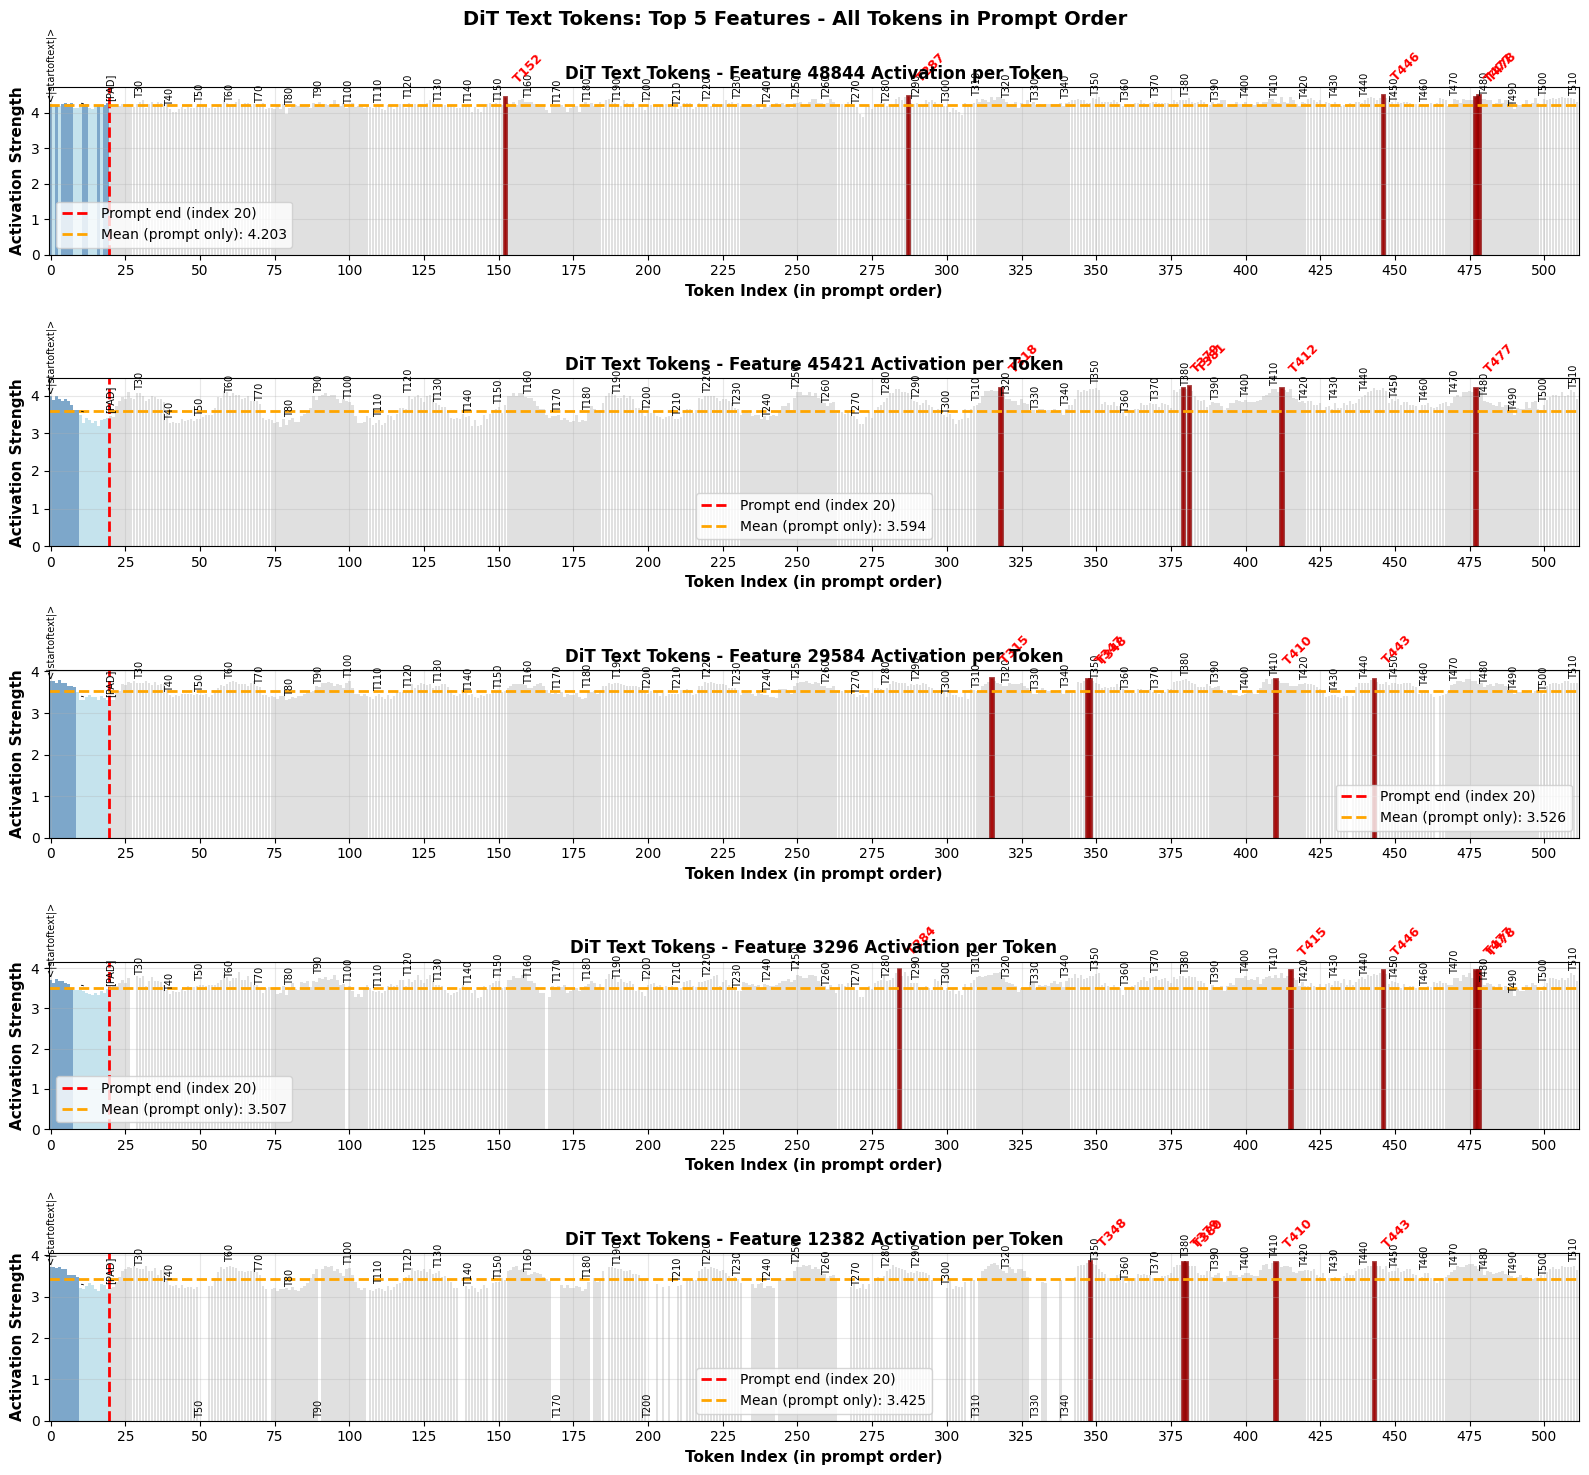


📝 DiT Text Prompt Tokens (actual tokens only, excluding padding):
  Token   0: <|startoftext|>                | Avg Activation: 0.0012
  Token   1: a                              | Avg Activation: 0.0012
  Token   2: woman                          | Avg Activation: 0.0012
  Token   3: with                           | Avg Activation: 0.0012
  Token   4: pink                           | Avg Activation: 0.0012
  Token   5: hair                           | Avg Activation: 0.0012
  Token   6: standing                       | Avg Activation: 0.0012
  Token   7: in                             | Avg Activation: 0.0012
  Token   8: a                              | Avg Activation: 0.0012
  Token   9: forest                         | Avg Activation: 0.0011
  Token  10: ,                              | Avg Activation: 0.0011
  Token  11: holding                        | Avg Activation: 0.0011
  Token  12: a                              | Avg Activation: 0.0011
  Token  13: sign                   

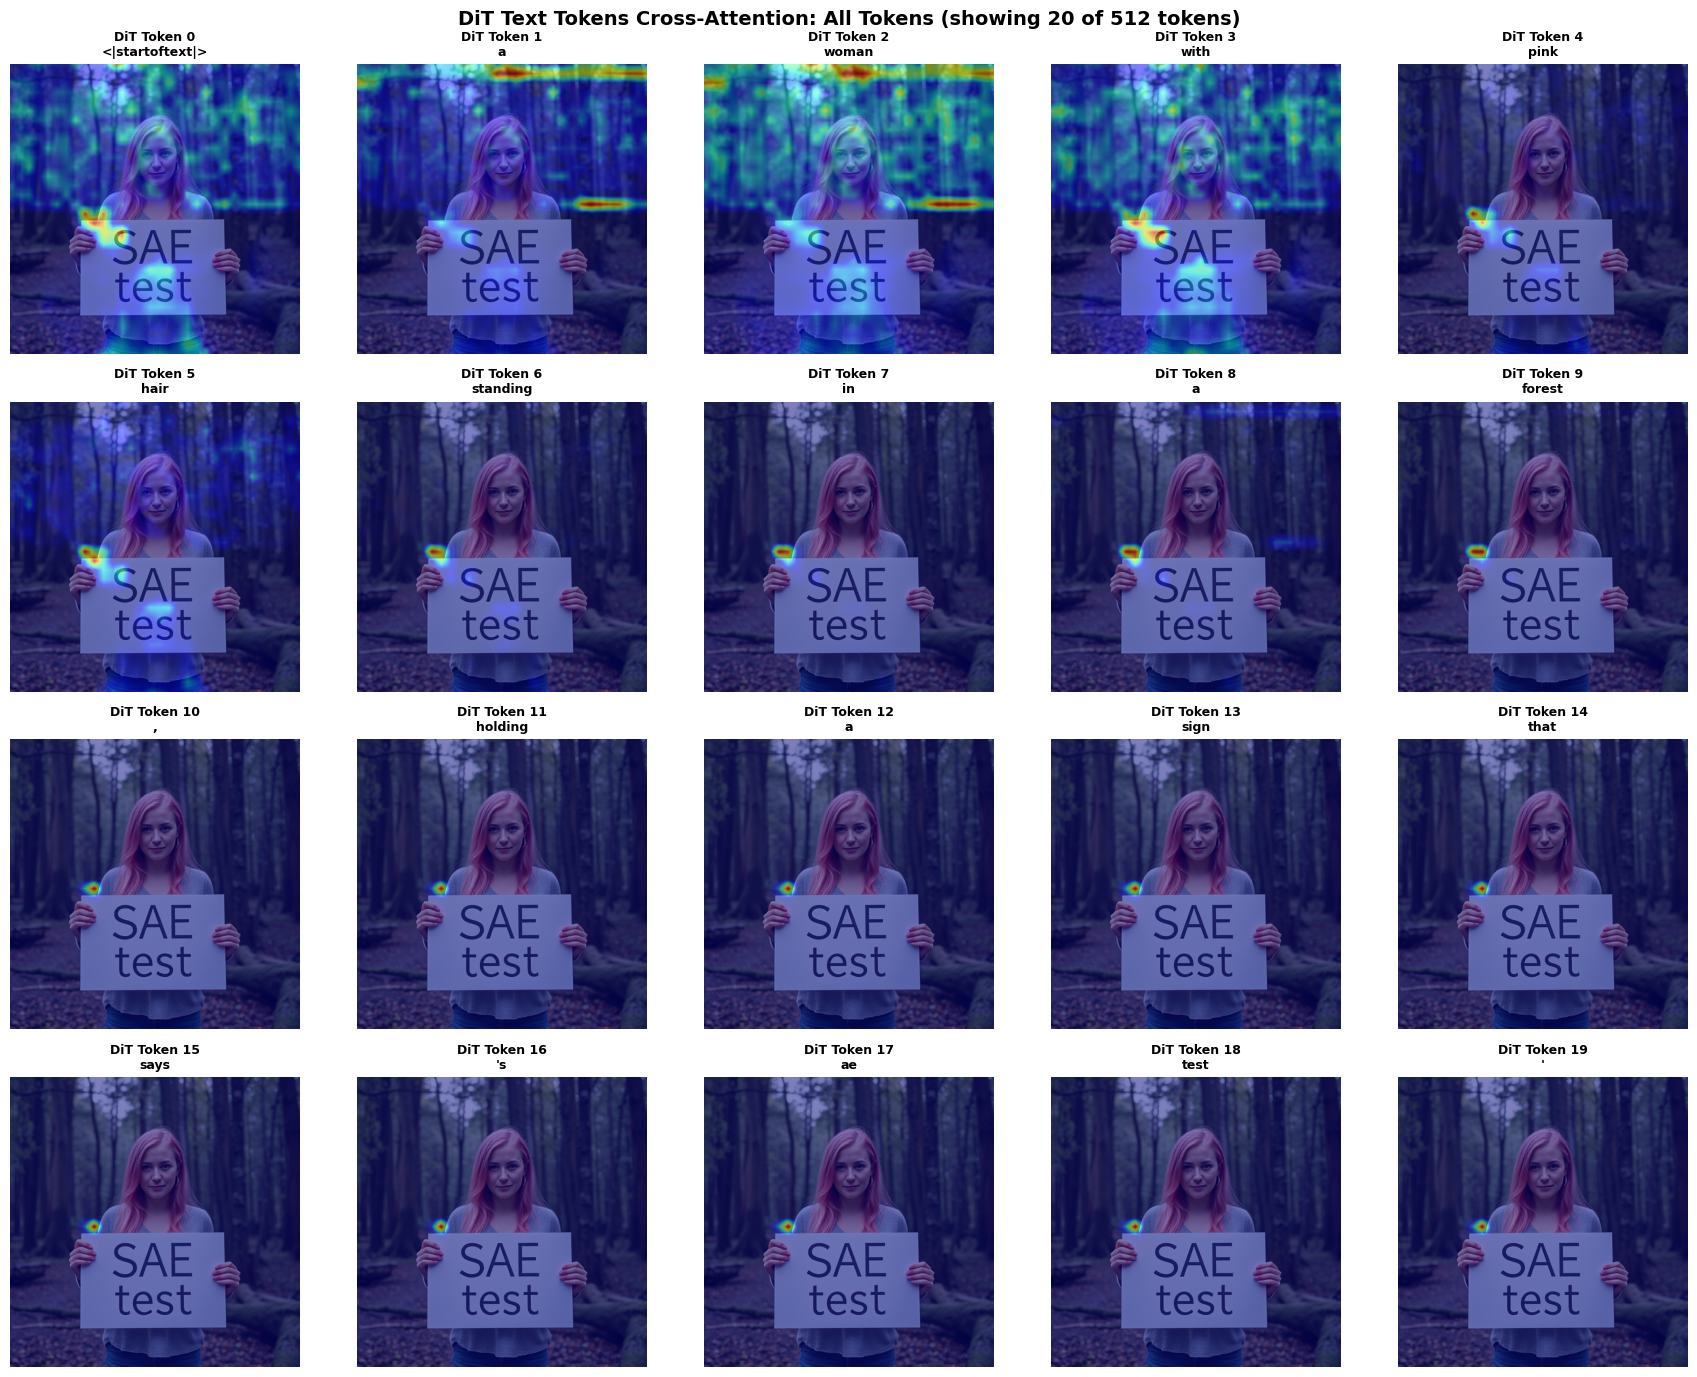


   ✅ Showing all 20 actual DiT text prompt tokens (padding tokens excluded)
   ⚠️  Note: 492 padding tokens (indices 20-511) were excluded

✅ DiT Text Tokens visualization complete


In [307]:
# Text Stream Visualization: Token Activation Plot & Cross-Attention Heatmaps
# This cell handles Text Stream (stream=1) which is sequence-based, not spatial

# Check if we're working with Text Stream
is_text_stream = first_code.startswith("transformer_blocks") and first_stream == 1

# Diagnostic output to explain why it might be skipped
print(f"\n🔍 Text Stream Detection:")
print(f"   Layer code: {first_code}")
print(f"   Starts with 'transformer_blocks': {first_code.startswith('transformer_blocks')}")
print(f"   Stream number: {first_stream}")
print(f"   Is Text Stream (stream=1): {is_text_stream}")
print(f"   Sparse maps shape: {sparse_maps.shape}")
print(f"   Sparse maps is 2D: {len(sparse_maps.shape) == 2}")

# For Text Stream, we need 2D sparse_maps (tokens, features)
# If it was incorrectly reshaped to 3D, flatten it back
if is_text_stream:
    if len(sparse_maps.shape) == 3:
        # Flatten back to 2D: (h, w, f) -> (h*w, f)
        h, w, f = sparse_maps.shape
        sparse_maps = sparse_maps.reshape(h * w, f)
        print("⚠️  Text Stream sparse_maps were reshaped to 3D - flattening back to 2D")
        print(f"   Reshaped from ({h}, {w}, {f}) to ({h*w}, {f})")

if is_text_stream and len(sparse_maps.shape) == 2:
    print("📝 Text Stream Detected - Generating Token Activation & Cross-Attention Visualizations")
    print("="*80)
    
    # Get tokenizer to decode token indices (if available)
    # FLUX uses T5 encoder, try to get the tokenizer from the pipeline
    can_decode_tokens = False
    tokenizer = None
    try:
        # Try to get tokenizer from FLUX pipeline's text encoder
        if hasattr(pipe, 'text_encoder') and hasattr(pipe.text_encoder, 'tokenizer'):
            tokenizer = pipe.text_encoder.tokenizer
            can_decode_tokens = True
        elif hasattr(pipe, 'tokenizer'):
            tokenizer = pipe.tokenizer
            can_decode_tokens = True
        else:
            # Fallback: try to load T5 tokenizer
            from transformers import T5Tokenizer
            # FLUX typically uses T5 v1.1 or similar
            tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
            can_decode_tokens = True
    except Exception as e:
        can_decode_tokens = False
        print(f"⚠️  Tokenizer not available - showing token indices only ({str(e)})")
    
    # 1. Token Index vs Activation Strength Plot
    print("\n1️⃣  Generating Token Activation Plot...")
    
    # Get token texts from prompt in order
    token_texts = {}
    token_ids_list = []
    num_tokens = sparse_maps.shape[0]  # Total tokens in sparse_maps (512 for text stream)
    
    # Determine actual prompt length (excluding padding)
    actual_prompt_length = num_tokens  # Default to all tokens if we can't determine
    
    if can_decode_tokens:
        try:
            # Tokenize the prompt to get all tokens in order
            encoded = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True, max_length=512)
            token_ids_list = encoded['input_ids'][0].cpu().tolist()
            
            # Find actual prompt length by looking for padding/EOS tokens
            # T5 typically uses 0 for padding, but check for EOS token too
            padding_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
            eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else 1
            
            # Find where padding starts (first padding or EOS token after actual content)
            actual_prompt_length = len(token_ids_list)
            for i, token_id in enumerate(token_ids_list):
                if token_id == padding_token_id or (i > 0 and token_id == eos_token_id):
                    actual_prompt_length = i
                    break
            
            # Map sequence positions to token texts
            for pos, token_id in enumerate(token_ids_list[:num_tokens]):
                try:
                    # Check if this is padding
                    if pos >= actual_prompt_length:
                        token_texts[pos] = f"[PAD]"
                    else:
                        token_text = tokenizer.decode([token_id])
                        token_texts[pos] = token_text.strip()
                except:
                    token_texts[pos] = f"<token_{token_id}>"
        except Exception as e:
            print(f"   ⚠️  Could not tokenize prompt: {e}")
    
    print(f"   📝 Actual prompt length: {actual_prompt_length} tokens (out of {num_tokens} total slots)")
    print(f"   ⚠️  Indices {actual_prompt_length}-{num_tokens-1} are padding tokens - will be filtered from analysis")
    
    # Get top features and their activations per token
    # IMPORTANT: Only use actual prompt tokens (exclude padding) for feature analysis
    num_top_features = 5
    sparse_maps_for_topk = sparse_maps
    if sparse_maps.dtype == torch.bfloat16:
        sparse_maps_for_topk = sparse_maps.float()
    
    # Filter out padding tokens when computing top features
    # Only average across actual prompt tokens (indices 0 to actual_prompt_length-1)
    prompt_tokens_only = sparse_maps_for_topk[:actual_prompt_length, :]  # (actual_prompt_length, features)
    top_features_mean = prompt_tokens_only.mean(axis=0)  # Average across actual prompt tokens only
    top_features_indices = top_features_mean.topk(num_top_features).indices.cpu().tolist()
    
    print(f"   ✅ Computing top features using only actual prompt tokens (indices 0-{actual_prompt_length-1})")
    
    # For each top feature, plot activation strength per token
    fig, axes = plt.subplots(num_top_features, 1, figsize=(16, 3*num_top_features))
    if num_top_features == 1:
        axes = [axes]
    
    for idx, feature_idx in enumerate(top_features_indices):
        ax = axes[idx]
        # Get activations for this feature across all tokens
        # Convert bfloat16 to float32 for numpy compatibility
        token_activations_tensor = sparse_maps[:, feature_idx]
        if token_activations_tensor.dtype == torch.bfloat16:
            token_activations_tensor = token_activations_tensor.float()
        token_activations = token_activations_tensor.cpu().numpy()
        
        # Plot all tokens, but highlight padding vs actual tokens
        colors = []
        for i, act in enumerate(token_activations):
            if i < actual_prompt_length:
                # Actual prompt token
                colors.append('steelblue' if act > token_activations[:actual_prompt_length].mean() else 'lightblue')
            else:
                # Padding token - use gray
                colors.append('lightgray')
        
        ax.bar(range(num_tokens), token_activations, alpha=0.7, color=colors)
        
        # Add vertical line to separate prompt from padding
        if actual_prompt_length < num_tokens:
            ax.axvline(actual_prompt_length - 0.5, color='red', linestyle='--', linewidth=2, 
                       label=f'Prompt end (index {actual_prompt_length})')
        ax.set_xlabel('Token Index (in prompt order)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Activation Strength', fontsize=11, fontweight='bold')
        ax.set_title(f'Feature {feature_idx} Activation per Token', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add token labels for all tokens (in prompt order)
        # Rotate labels and show every Nth token to avoid overcrowding
        label_interval = max(1, num_tokens // 50)  # Show ~50 labels max
        for token_idx in range(0, num_tokens, label_interval):
            token_text = token_texts.get(token_idx, f"T{token_idx}")
            # Truncate long token texts
            display_text = token_text[:15] if len(token_text) > 15 else token_text
            ax.text(token_idx, token_activations[token_idx] + token_activations.max() * 0.02, 
                   display_text, fontsize=7, rotation=90, ha='center', va='bottom')
        
        # Highlight top 5 activating tokens (only from actual prompt tokens, not padding)
        prompt_activations = token_activations[:actual_prompt_length]
        top_token_indices = np.argsort(prompt_activations)[-5:][::-1]  # Top 5 from prompt only
        for token_idx in top_token_indices:
            ax.bar(token_idx, token_activations[token_idx], color='red', alpha=0.8, edgecolor='darkred', linewidth=2)
            token_text = token_texts.get(token_idx, f"T{token_idx}")
            ax.text(token_idx, token_activations[token_idx] + token_activations.max() * 0.05, 
                   f'  {token_text[:20]}', 
                   fontsize=9, rotation=45, ha='left', fontweight='bold', color='red')
        
        # Add mean line (computed from actual prompt tokens only)
        mean_activation = prompt_activations.mean()
        ax.axhline(mean_activation, color='orange', linestyle='--', linewidth=2,
                  label=f'Mean (prompt only): {mean_activation:.3f}')
        ax.legend()
        
        # Set x-axis to show all token indices
        ax.set_xlim(-0.5, num_tokens - 0.5)
        ax.set_xticks(range(0, num_tokens, max(1, num_tokens // 20)))  # Show ~20 tick marks
    
    plt.suptitle(f'Text Stream: Top {num_top_features} Features - All Tokens in Prompt Order', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print token list in prompt order (only actual prompt tokens)
    print(f"\n📝 Prompt Tokens (actual tokens only, excluding padding):")
    print("="*80)
    for i in range(min(actual_prompt_length, 50)):
        token_text = token_texts.get(i, f"<token_{i}>")
        activation_avg = float(sparse_maps_for_topk[i, :].mean().item())
        print(f"  Token {i:3d}: {token_text:30s} | Avg Activation: {activation_avg:.4f}")
    if actual_prompt_length > 50:
        print(f"  ... (showing first 50 of {actual_prompt_length} actual tokens)")
    if actual_prompt_length < num_tokens:
        print(f"\n  ⚠️  Note: Indices {actual_prompt_length}-{num_tokens-1} are padding tokens (ignored)")
    print("="*80)
    
    # 2. Cross-Attention Heatmaps
    print("\n2️⃣  Generating Cross-Attention Heatmaps...")
    print("   Extracting attention maps from MMDiT attention layers...")
    
    # Function to extract cross-attention maps
    def extract_cross_attention_maps(code, prompt, num_steps=1, all_tokens=True, max_tokens=None):
        """
        Extract cross-attention maps for text tokens.
        
        Args:
            code: Layer code
            prompt: Text prompt
            num_steps: Number of inference steps
            all_tokens: If True, extract for all tokens in prompt. If False, use top activating tokens
            max_tokens: Maximum number of tokens to visualize (None = all)
        
        Returns attention maps: (height, width) for each token
        """
        block = code_to_block[code]
        
        # Determine which tokens to visualize
        # IMPORTANT: Only visualize actual prompt tokens, exclude padding
        if all_tokens:
            # Get actual prompt tokens only (exclude padding)
            if can_decode_tokens and len(token_ids_list) > 0:
                # Use actual prompt tokens (up to actual_prompt_length)
                token_indices = list(range(min(actual_prompt_length, num_tokens)))
            else:
                # Fallback: use all tokens up to a reasonable limit (assume prompt is < 100 tokens)
                token_indices = list(range(min(100, num_tokens)))
            
            # Limit if max_tokens specified
            if max_tokens is not None:
                token_indices = token_indices[:max_tokens]
            
            print(f"   Extracting attention maps for {len(token_indices)} actual prompt tokens (excluding padding)")
        else:
            # Get top activating tokens (only from actual prompt tokens, exclude padding)
            sparse_maps_for_avg = sparse_maps
            if sparse_maps.dtype == torch.bfloat16:
                sparse_maps_for_avg = sparse_maps.float()
            # Only consider actual prompt tokens
            prompt_tokens_only = sparse_maps_for_avg[:actual_prompt_length, :]
            token_activations = prompt_tokens_only.mean(axis=1)  # Average across features
            top_tokens = max_tokens or 5
            token_indices = token_activations.topk(top_tokens).indices.cpu().tolist()
            print(f"   Top {len(token_indices)} activating tokens (from actual prompt only): {token_indices}")
        
        # Storage for attention maps
        attention_maps = {}
        
        # Hook into the attention module to extract attention weights
        # FLUX MMDiT attention: image queries attend to text keys
        # The output tuple is (image_stream, text_stream), but we need both to compute cross-attention
        def attention_hook(module, input, output):
            # Try to access attention weights from the module
            # Different FLUX implementations may store attention differently
            if hasattr(module, 'last_attention_weights'):
                # Some implementations store attention weights
                attn_weights = module.last_attention_weights
                if attn_weights is not None:
                    # attn_weights shape: (batch, num_heads, num_queries, num_keys)
                    # Average over heads
                    attn_weights = attn_weights.mean(dim=1)  # (batch, num_queries, num_keys)
                    
                    for token_idx in token_indices:
                        if token_idx < attn_weights.shape[2]:
                            token_attention = attn_weights[0, :, token_idx]  # (num_queries,)
                            if len(token_attention) == 1024:
                                # Convert bfloat16 to float32 for numpy compatibility
                                if token_attention.dtype == torch.bfloat16:
                                    token_attention = token_attention.float()
                                attention_map = token_attention.reshape(32, 32).cpu().numpy()
                                attention_maps[token_idx] = attention_map
            else:
                # Fallback: compute attention from query/key outputs
                # For MMDiT, output is (image_stream, text_stream)
                # We need image stream (query) to compute which image positions attend to text tokens
                if isinstance(output, tuple) and len(output) == 2:
                    image_stream, text_stream = output
                    # image_stream: (batch, 1024, dim) - image tokens (queries)
                    # text_stream: (batch, 512, dim) - text tokens (keys)
                    
                    if len(image_stream.shape) == 3 and len(text_stream.shape) == 3:
                        batch, num_queries, dim = image_stream.shape
                        batch_k, num_keys, dim_k = text_stream.shape
                        
                        # Ensure we're working with compatible dtypes for computation
                        # Convert to float32 if needed for stable computation
                        image_stream_comp = image_stream.float() if image_stream.dtype == torch.bfloat16 else image_stream
                        text_stream_comp = text_stream.float() if text_stream.dtype == torch.bfloat16 else text_stream
                        
                        # Compute attention scores: Q @ K^T / sqrt(dim)
                        # This shows which image positions attend to which text tokens
                        scale = 1.0 / np.sqrt(float(dim))
                        attention_scores = torch.matmul(image_stream_comp, text_stream_comp.transpose(-2, -1)) * scale  # (batch, num_queries, num_keys)
                        attention_scores = torch.softmax(attention_scores, dim=-1)  # Normalize
                        
                        # Store attention for all specified tokens
                        for token_idx in token_indices:
                            if token_idx < num_keys:
                                # Get attention from all image positions to this text token
                                token_attention = attention_scores[0, :, token_idx]  # (num_queries,)
                                
                                # Reshape to spatial - calculate dimensions dynamically
                                num_image_tokens = len(token_attention)
                                spatial_dims = calculate_spatial_dims_from_tokens(num_image_tokens)
                                if spatial_dims:
                                    h, w = spatial_dims
                                    # Convert bfloat16 to float32 for numpy compatibility
                                    if token_attention.dtype == torch.bfloat16:
                                        token_attention = token_attention.float()
                                    attention_map = token_attention.reshape(h, w).cpu().numpy()
                                    attention_maps[token_idx] = attention_map
        
        hook_handle = pipe.transformer.get_submodule(block).register_forward_hook(attention_hook)
        
        try:
            # Generate to capture attention
            _ = pipe(
                prompt=prompt,
                height=test_height,
                width=test_width,
                num_inference_steps=num_steps,
                guidance_scale=3.5 if num_steps > 1 else 0.0,
                generator=torch.Generator(device="cuda").manual_seed(42)
            )
        finally:
            hook_handle.remove()
        
        return attention_maps, token_indices

# Function to extract cross-attention maps
    def extract_cross_attention_maps(code, prompt, num_steps=1, all_tokens=True, max_tokens=None):
        """
        Extract cross-attention maps for text tokens.
        """
        block = code_to_block[code]
        
        # Determine which tokens to visualize
        if all_tokens:
            if can_decode_tokens and len(token_ids_list) > 0:
                token_indices = list(range(min(actual_prompt_length, num_tokens)))
            else:
                token_indices = list(range(min(100, num_tokens)))
            
            if max_tokens is not None:
                token_indices = token_indices[:max_tokens]
            print(f"   Extracting attention maps for {len(token_indices)} actual prompt tokens")
        else:
            sparse_maps_for_avg = sparse_maps
            if sparse_maps.dtype == torch.bfloat16:
                sparse_maps_for_avg = sparse_maps.float()
            prompt_tokens_only = sparse_maps_for_avg[:actual_prompt_length, :]
            token_activations = prompt_tokens_only.mean(axis=1)
            top_tokens = max_tokens or 5
            token_indices = token_activations.topk(top_tokens).indices.cpu().tolist()
            print(f"   Top {len(token_indices)} activating tokens: {token_indices}")
        
        attention_maps = {}
        
        # 1. GET DYNAMIC RESOLUTION FROM ORIGINAL IMAGE
        # This ensures the attention map matches the aspect ratio of the image you are overlaying on
        target_height = original_image.height
        target_width = original_image.width
        print(f"   ℹ️  Using resolution from original image: {target_width}x{target_height}")

        def attention_hook(module, input, output):
            if hasattr(module, 'last_attention_weights'):
                attn_weights = module.last_attention_weights
                if attn_weights is not None:
                    attn_weights = attn_weights.mean(dim=1)
                    for token_idx in token_indices:
                        if token_idx < attn_weights.shape[2]:
                            token_attention = attn_weights[0, :, token_idx]
                            if token_attention.dtype == torch.bfloat16:
                                token_attention = token_attention.float()
                            
                            # DYNAMIC RESHAPE
                            num_tokens = len(token_attention)
                            grid_h = target_height // 16
                            grid_w = target_width // 16
                            
                            try:
                                attention_map = token_attention.reshape(grid_h, grid_w).cpu().numpy()
                                attention_maps[token_idx] = attention_map
                            except Exception as e:
                                print(f"Error reshaping token {token_idx}: {e}")
            else:
                if isinstance(output, tuple) and len(output) == 2:
                    image_stream, text_stream = output
                    if len(image_stream.shape) == 3 and len(text_stream.shape) == 3:
                        batch, num_queries, dim = image_stream.shape
                        batch_k, num_keys, dim_k = text_stream.shape
                        
                        image_stream_comp = image_stream.float() if image_stream.dtype == torch.bfloat16 else image_stream
                        text_stream_comp = text_stream.float() if text_stream.dtype == torch.bfloat16 else text_stream
                        
                        scale = 1.0 / np.sqrt(float(dim))
                        attention_scores = torch.matmul(image_stream_comp, text_stream_comp.transpose(-2, -1)) * scale
                        attention_scores = torch.softmax(attention_scores, dim=-1)
                        
                        for token_idx in token_indices:
                            if token_idx < num_keys:
                                token_attention = attention_scores[0, :, token_idx]
                                
                                # DYNAMIC RESHAPE
                                grid_h = target_height // 16
                                grid_w = target_width // 16
                                
                                if token_attention.dtype == torch.bfloat16:
                                    token_attention = token_attention.float()
                                
                                try:
                                    attention_map = token_attention.reshape(grid_h, grid_w).cpu().numpy()
                                    attention_maps[token_idx] = attention_map
                                except Exception as e:
                                    print(f"Error reshaping: {e}")

        hook_handle = pipe.transformer.get_submodule(block).register_forward_hook(attention_hook)
        
        try:
            # 2. USE DYNAMIC RESOLUTION IN PIPE CALL
            _ = pipe(
                prompt=prompt,
                height=target_height,   # FIX: Use variable, not 512
                width=target_width,     # FIX: Use variable, not 512
                num_inference_steps=num_steps,
                guidance_scale=3.5 if num_steps > 1 else 0.0,
                generator=torch.Generator(device="cuda").manual_seed(42) # Ensure this seed matches your original gen!
            )
        finally:
            hook_handle.remove()
        
        return attention_maps, token_indices
        
    # Extract cross-attention maps for actual prompt tokens only (exclude padding)
    # Set max_tokens_to_visualize to None to show all actual prompt tokens, or a number to limit
    max_tokens_to_visualize = None  # Set to None for all actual prompt tokens, or e.g., 50 to limit
    if max_tokens_to_visualize is not None:
        max_tokens_to_visualize = min(max_tokens_to_visualize, actual_prompt_length)
    else:
        max_tokens_to_visualize = actual_prompt_length  # Only show actual prompt tokens
    
    try:
        attention_maps_dict, token_indices = extract_cross_attention_maps(
            first_code, prompt, num_steps=1, all_tokens=True, max_tokens=max_tokens_to_visualize
        )
        
        if attention_maps_dict:
            print(f"   ✅ Extracted attention maps for {len(attention_maps_dict)} tokens")
            
            # Sort token indices to show in prompt order
            sorted_token_indices = sorted(attention_maps_dict.keys())
            
            # Plot cross-attention heatmaps in a grid
            num_maps = len(attention_maps_dict)
            # Use more columns for better layout when there are many tokens
            if num_maps <= 10:
                cols = num_maps
                rows = 1
            elif num_maps <= 25:
                cols = 5
                rows = (num_maps + cols - 1) // cols
            else:
                # For many tokens, use 6 columns
                cols = 6
                rows = (num_maps + cols - 1) // cols
            
            fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.5*rows))
            if num_maps == 1:
                axes = [axes]
            elif rows == 1:
                axes = axes if isinstance(axes, np.ndarray) else [axes]
            else:
                axes = axes.flatten()
            
            for plot_idx, token_idx in enumerate(sorted_token_indices):
                if plot_idx >= len(axes):
                    break
                    
                ax = axes[plot_idx]
                attention_map = attention_maps_dict[token_idx]
                
                # Get actual image dimensions (not hardcoded)
                img_array = np.array(original_image.convert("RGB"))
                img_height, img_width = img_array.shape[:2]
                
                # Upsample attention map to actual image size (h×w → img_height×img_width)
                h_attn, w_attn = attention_map.shape
                if has_scipy:
                    zoom_factor_h = img_height / h_attn
                    zoom_factor_w = img_width / w_attn
                    attention_upsampled = zoom(attention_map, (zoom_factor_h, zoom_factor_w), order=1)
                else:
                    # Simple upsampling using numpy
                    factor_h = img_height // h_attn
                    factor_w = img_width // w_attn
                    attention_upsampled = np.kron(attention_map, np.ones((factor_h, factor_w)))
                    # Crop or pad to exactly match image dimensions if needed
                    if attention_upsampled.shape != (img_height, img_width):
                        # Crop or pad to match
                        h_upsampled, w_upsampled = attention_upsampled.shape
                        if h_upsampled > img_height:
                            attention_upsampled = attention_upsampled[:img_height, :]
                        elif h_upsampled < img_height:
                            # Pad with zeros
                            pad_h = img_height - h_upsampled
                            attention_upsampled = np.pad(attention_upsampled, ((0, pad_h), (0, 0)), mode='constant')
                        if w_upsampled > img_width:
                            attention_upsampled = attention_upsampled[:, :img_width]
                        elif w_upsampled < img_width:
                            # Pad with zeros
                            pad_w = img_width - w_upsampled
                            attention_upsampled = np.pad(attention_upsampled, ((0, 0), (0, pad_w)), mode='constant')
                
                # Normalize
                attention_normalized = (attention_upsampled - attention_upsampled.min()) / (
                    attention_upsampled.max() - attention_upsampled.min() + 1e-8
                )
                
                # Overlay on original image
                heatmap_rgba = plt.cm.jet(attention_normalized)[:, :, :3]
                heatmap_rgba = (heatmap_rgba * 255).astype(np.uint8)
                
                # Ensure shapes match before blending
                if heatmap_rgba.shape[:2] != img_array.shape[:2]:
                    # Resize heatmap to match image exactly
                    from PIL import Image
                    heatmap_img = Image.fromarray(heatmap_rgba)
                    heatmap_img = heatmap_img.resize((img_width, img_height), Image.Resampling.LANCZOS)
                    heatmap_rgba = np.array(heatmap_img)
                
                # Blend
                alpha = 0.5
                blended = (alpha * heatmap_rgba + (1 - alpha) * img_array).astype(np.uint8)
                
                ax.imshow(blended)
                
                # Get token text from token_texts dict (already computed above)
                token_text = token_texts.get(token_idx, f"T{token_idx}")
                if len(token_text) > 20:
                    token_text = token_text[:20] + "..."
                
                title = f"Token {token_idx}\n{token_text}"
                ax.set_title(title, fontsize=9, fontweight='bold')
                ax.axis('off')
            
            # Hide unused subplots
            for idx in range(num_maps, len(axes)):
                axes[idx].axis('off')
            
            plt.suptitle(f'Cross-Attention Heatmaps: All Text Tokens (showing {num_maps} of {num_tokens} tokens)', 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            if max_tokens_to_visualize is not None and actual_prompt_length > max_tokens_to_visualize:
                print(f"\n   ℹ️  Note: Showing first {max_tokens_to_visualize} actual prompt tokens. Total actual tokens: {actual_prompt_length}")
                print(f"   💡 To see all actual prompt tokens, set max_tokens_to_visualize = None in the code")
            else:
                print(f"\n   ✅ Showing all {num_maps} actual prompt tokens (padding tokens excluded)")
                if actual_prompt_length < num_tokens:
                    print(f"   ⚠️  Note: {num_tokens - actual_prompt_length} padding tokens (indices {actual_prompt_length}-{num_tokens-1}) were excluded")
        else:
            print("   ⚠️  Could not extract attention maps - attention hook may need adjustment")
    except Exception as e:
        print(f"   ⚠️  Error extracting cross-attention maps: {str(e)}")
        print("   This is expected if attention mechanism structure differs")
        import traceback
        traceback.print_exc()
    
    print("\n✅ Text Stream visualization complete")
    print("="*80)
else:
    print("\nℹ️  Skipping MMDiT Text Stream visualization")
    print("="*80)
    if not first_code.startswith("transformer_blocks"):
        print(f"   Reason: Layer code '{first_code}' is not a MMDiT layer")
        print(f"   💡 MMDiT layers start with 'transformer_blocks'")
        if first_code.startswith("single_transformer_blocks"):
            print(f"   💡 This is a DiT layer - use DiT Text Tokens analysis below")
    elif first_stream != 1:
        print(f"   Reason: Stream number is {first_stream}, not 1 (Text Stream)")
        print(f"   💡 Stream 0 = Image Stream (spatial), Stream 1 = Text Stream (sequence-based)")
        print(f"   💡 For Text Stream visualization, you need stream=1")
    elif len(sparse_maps.shape) != 2:
        print(f"   Reason: Sparse maps shape is {sparse_maps.shape} (not 2D)")
        print(f"   💡 Text Stream requires 2D sparse_maps: (tokens, features)")
        print(f"   💡 Current shape suggests it was reshaped to spatial (3D)")
    print("="*80)

# ============================================================================
# DiT Text Tokens Analysis (for DiT layers with concatenated streams)
# ============================================================================
# Check if we have DiT text sparse_maps (from DiT fused stream)
# Ensure is_dit is defined (from Cell 4)
if 'is_dit' not in locals():
    is_dit = first_code.startswith("single_transformer_blocks")

if dit_text_sparse_maps is not None and is_dit:
    print("\n" + "="*80)
    print("📝 DiT Text Tokens Detected - Generating Token Activation & Cross-Attention Visualizations")
    print("="*80)
    
    # Use dit_text_sparse_maps for analysis (shape: (512, features))
    dit_sparse_maps = dit_text_sparse_maps
    
    # Get tokenizer (reuse from above if available, otherwise try to get it)
    if 'can_decode_tokens' not in locals():
        can_decode_tokens = False
    if 'tokenizer' not in locals():
        tokenizer = None
    
    if not can_decode_tokens:
        try:
            if hasattr(pipe, 'text_encoder') and hasattr(pipe.text_encoder, 'tokenizer'):
                tokenizer = pipe.text_encoder.tokenizer
                can_decode_tokens = True
            elif hasattr(pipe, 'tokenizer'):
                tokenizer = pipe.tokenizer
                can_decode_tokens = True
            else:
                from transformers import T5Tokenizer
                tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
                can_decode_tokens = True
        except Exception as e:
            can_decode_tokens = False
            print(f"⚠️  Tokenizer not available - showing token indices only ({str(e)})")
    
    # 1. Token Index vs Activation Strength Plot for DiT Text Tokens
    print("\n1️⃣  Generating DiT Text Token Activation Plot...")
    
    # Get token texts from prompt in order
    dit_token_texts = {}
    dit_token_ids_list = []
    dit_num_tokens = dit_sparse_maps.shape[0]  # Should be 512
    
    # Determine actual prompt length (excluding padding) for DiT text tokens
    dit_actual_prompt_length = dit_num_tokens  # Default to all tokens if we can't determine
    
    if can_decode_tokens:
        try:
            encoded = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True, max_length=512)
            dit_token_ids_list = encoded['input_ids'][0].cpu().tolist()
            
            # Find actual prompt length by looking for padding/EOS tokens
            padding_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
            eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else 1
            
            dit_actual_prompt_length = len(dit_token_ids_list)
            for i, token_id in enumerate(dit_token_ids_list):
                if token_id == padding_token_id or (i > 0 and token_id == eos_token_id):
                    dit_actual_prompt_length = i
                    break
            
            for pos, token_id in enumerate(dit_token_ids_list[:dit_num_tokens]):
                try:
                    if pos >= dit_actual_prompt_length:
                        dit_token_texts[pos] = f"[PAD]"
                    else:
                        token_text = tokenizer.decode([token_id])
                        dit_token_texts[pos] = token_text.strip()
                except:
                    dit_token_texts[pos] = f"<token_{token_id}>"
        except Exception as e:
            print(f"   ⚠️  Could not tokenize prompt: {e}")
    
    print(f"   📝 Actual DiT text prompt length: {dit_actual_prompt_length} tokens (out of {dit_num_tokens} total slots)")
    print(f"   ⚠️  Indices {dit_actual_prompt_length}-{dit_num_tokens-1} are padding tokens - will be filtered from analysis")
    
    # Get top features and their activations per token
    # IMPORTANT: Only use actual prompt tokens (exclude padding) for feature analysis
    num_top_features = 5
    dit_sparse_maps_for_topk = dit_sparse_maps
    if dit_sparse_maps.dtype == torch.bfloat16:
        dit_sparse_maps_for_topk = dit_sparse_maps.float()
    
    # Filter out padding tokens when computing top features
    dit_prompt_tokens_only = dit_sparse_maps_for_topk[:dit_actual_prompt_length, :]
    dit_top_features_mean = dit_prompt_tokens_only.mean(axis=0)  # Average across actual prompt tokens only
    dit_top_features_indices = dit_top_features_mean.topk(num_top_features).indices.cpu().tolist()
    
    print(f"   ✅ Computing top features using only actual prompt tokens (indices 0-{dit_actual_prompt_length-1})")
    
    # For each top feature, plot activation strength per token
    fig, axes = plt.subplots(num_top_features, 1, figsize=(16, 3*num_top_features))
    if num_top_features == 1:
        axes = [axes]
    
    for idx, feature_idx in enumerate(dit_top_features_indices):
        ax = axes[idx]
        token_activations_tensor = dit_sparse_maps[:, feature_idx]
        if token_activations_tensor.dtype == torch.bfloat16:
            token_activations_tensor = token_activations_tensor.float()
        token_activations = token_activations_tensor.cpu().numpy()
        
        # Plot all tokens, but highlight padding vs actual tokens
        colors = []
        for i, act in enumerate(token_activations):
            if i < dit_actual_prompt_length:
                colors.append('steelblue' if act > token_activations[:dit_actual_prompt_length].mean() else 'lightblue')
            else:
                colors.append('lightgray')  # Padding token
        
        ax.bar(range(dit_num_tokens), token_activations, alpha=0.7, color=colors)
        
        # Add vertical line to separate prompt from padding
        if dit_actual_prompt_length < dit_num_tokens:
            ax.axvline(dit_actual_prompt_length - 0.5, color='red', linestyle='--', linewidth=2, 
                       label=f'Prompt end (index {dit_actual_prompt_length})')
        ax.set_xlabel('Token Index (in prompt order)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Activation Strength', fontsize=11, fontweight='bold')
        ax.set_title(f'DiT Text Tokens - Feature {feature_idx} Activation per Token', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add token labels
        label_interval = max(1, dit_num_tokens // 50)
        for token_idx in range(0, dit_num_tokens, label_interval):
            token_text = dit_token_texts.get(token_idx, f"T{token_idx}")
            display_text = token_text[:15] if len(token_text) > 15 else token_text
            ax.text(token_idx, token_activations[token_idx] + token_activations.max() * 0.02, 
                   display_text, fontsize=7, rotation=90, ha='center', va='bottom')
        
        # Highlight top 5 activating tokens
        top_token_indices = np.argsort(token_activations)[-5:][::-1]
        for token_idx in top_token_indices:
            ax.bar(token_idx, token_activations[token_idx], color='red', alpha=0.8, edgecolor='darkred', linewidth=2)
            token_text = dit_token_texts.get(token_idx, f"T{token_idx}")
            ax.text(token_idx, token_activations[token_idx] + token_activations.max() * 0.05, 
                   f'  {token_text[:20]}', 
                   fontsize=9, rotation=45, ha='left', fontweight='bold', color='red')
        
        # Add mean line (computed from actual prompt tokens only)
        dit_prompt_activations = token_activations[:dit_actual_prompt_length]
        mean_activation = dit_prompt_activations.mean()
        ax.axhline(mean_activation, color='orange', linestyle='--', linewidth=2,
                  label=f'Mean (prompt only): {mean_activation:.3f}')
        ax.legend()
        ax.set_xlim(-0.5, dit_num_tokens - 0.5)
        ax.set_xticks(range(0, dit_num_tokens, max(1, dit_num_tokens // 20)))
    
    plt.suptitle(f'DiT Text Tokens: Top {num_top_features} Features - All Tokens in Prompt Order', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print token list (only actual prompt tokens)
    print(f"\n📝 DiT Text Prompt Tokens (actual tokens only, excluding padding):")
    print("="*80)
    for i in range(min(dit_actual_prompt_length, 50)):
        token_text = dit_token_texts.get(i, f"<token_{i}>")
        activation_avg = float(dit_sparse_maps_for_topk[i, :].mean().item())
        print(f"  Token {i:3d}: {token_text:30s} | Avg Activation: {activation_avg:.4f}")
    if dit_actual_prompt_length > 50:
        print(f"  ... (showing first 50 of {dit_actual_prompt_length} actual tokens)")
    if dit_actual_prompt_length < dit_num_tokens:
        print(f"\n  ⚠️  Note: Indices {dit_actual_prompt_length}-{dit_num_tokens-1} are padding tokens (ignored)")
    print("="*80)
    
    # 2. Cross-Attention Heatmaps for DiT Text Tokens
    print("\n2️⃣  Generating Cross-Attention Heatmaps for DiT Text Tokens...")
    print("   Extracting attention maps from DiT attention layers...")
    
    # Function to extract cross-attention maps for DiT layers
    def extract_cross_attention_maps(code, prompt, num_steps=1, all_tokens=True, max_tokens=None):
        """
        Extract cross-attention maps for text tokens.
        """
        block = code_to_block[code]
        
        # Determine which tokens to visualize
        if all_tokens:
            if can_decode_tokens and len(token_ids_list) > 0:
                token_indices = list(range(min(actual_prompt_length, num_tokens)))
            else:
                token_indices = list(range(min(100, num_tokens)))
            
            if max_tokens is not None:
                token_indices = token_indices[:max_tokens]
            print(f"   Extracting attention maps for {len(token_indices)} actual prompt tokens")
        else:
            sparse_maps_for_avg = sparse_maps
            if sparse_maps.dtype == torch.bfloat16:
                sparse_maps_for_avg = sparse_maps.float()
            prompt_tokens_only = sparse_maps_for_avg[:actual_prompt_length, :]
            token_activations = prompt_tokens_only.mean(axis=1)
            top_tokens = max_tokens or 5
            token_indices = token_activations.topk(top_tokens).indices.cpu().tolist()
            print(f"   Top {len(token_indices)} activating tokens: {token_indices}")
        
        attention_maps = {}
        
        # 1. GET DYNAMIC RESOLUTION FROM ORIGINAL IMAGE
        # This ensures the attention map matches the aspect ratio of the image you are overlaying on
        target_height = original_image.height
        target_width = original_image.width
        print(f"   ℹ️  Using resolution from original image: {target_width}x{target_height}")

        def attention_hook(module, input, output):
            if hasattr(module, 'last_attention_weights'):
                attn_weights = module.last_attention_weights
                if attn_weights is not None:
                    attn_weights = attn_weights.mean(dim=1)
                    for token_idx in token_indices:
                        if token_idx < attn_weights.shape[2]:
                            token_attention = attn_weights[0, :, token_idx]
                            if token_attention.dtype == torch.bfloat16:
                                token_attention = token_attention.float()
                            
                            # DYNAMIC RESHAPE
                            num_tokens = len(token_attention)
                            grid_h = target_height // 16
                            grid_w = target_width // 16
                            
                            try:
                                attention_map = token_attention.reshape(grid_h, grid_w).cpu().numpy()
                                attention_maps[token_idx] = attention_map
                            except Exception as e:
                                print(f"Error reshaping token {token_idx}: {e}")
            else:
                if isinstance(output, tuple) and len(output) == 2:
                    image_stream, text_stream = output
                    if len(image_stream.shape) == 3 and len(text_stream.shape) == 3:
                        batch, num_queries, dim = image_stream.shape
                        batch_k, num_keys, dim_k = text_stream.shape
                        
                        image_stream_comp = image_stream.float() if image_stream.dtype == torch.bfloat16 else image_stream
                        text_stream_comp = text_stream.float() if text_stream.dtype == torch.bfloat16 else text_stream
                        
                        scale = 1.0 / np.sqrt(float(dim))
                        attention_scores = torch.matmul(image_stream_comp, text_stream_comp.transpose(-2, -1)) * scale
                        attention_scores = torch.softmax(attention_scores, dim=-1)
                        
                        for token_idx in token_indices:
                            if token_idx < num_keys:
                                token_attention = attention_scores[0, :, token_idx]
                                
                                # DYNAMIC RESHAPE
                                grid_h = target_height // 16
                                grid_w = target_width // 16
                                
                                if token_attention.dtype == torch.bfloat16:
                                    token_attention = token_attention.float()
                                
                                try:
                                    attention_map = token_attention.reshape(grid_h, grid_w).cpu().numpy()
                                    attention_maps[token_idx] = attention_map
                                except Exception as e:
                                    print(f"Error reshaping: {e}")

        hook_handle = pipe.transformer.get_submodule(block).register_forward_hook(attention_hook)
        
        try:
            # 2. USE DYNAMIC RESOLUTION IN PIPE CALL
            _ = pipe(
                prompt=prompt,
                height=target_height,   # FIX: Use variable, not 512
                width=target_width,     # FIX: Use variable, not 512
                num_inference_steps=num_steps,
                guidance_scale=3.5 if num_steps > 1 else 0.0,
                generator=torch.Generator(device="cuda").manual_seed(42) # Ensure this seed matches your original gen!
            )
        finally:
            hook_handle.remove()
        
        return attention_maps, token_indices
    
    # Extract cross-attention maps for actual DiT text prompt tokens only (exclude padding)
    max_tokens_to_visualize = None
    if max_tokens_to_visualize is not None:
        max_tokens_to_visualize = min(max_tokens_to_visualize, dit_actual_prompt_length)
    else:
        max_tokens_to_visualize = dit_actual_prompt_length  # Only show actual prompt tokens
    
    try:
        dit_attention_maps_dict, dit_token_indices = extract_dit_cross_attention_maps(
            first_code, prompt, num_steps=1, all_tokens=True, max_tokens=max_tokens_to_visualize
        )
        
        if dit_attention_maps_dict:
            print(f"   ✅ Extracted attention maps for {len(dit_attention_maps_dict)} DiT text tokens")
            
            sorted_token_indices = sorted(dit_attention_maps_dict.keys())
            num_maps = len(dit_attention_maps_dict)
            
            if num_maps <= 10:
                cols = num_maps
                rows = 1
            elif num_maps <= 25:
                cols = 5
                rows = (num_maps + cols - 1) // cols
            else:
                cols = 6
                rows = (num_maps + cols - 1) // cols
            
            fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.5*rows))
            if num_maps == 1:
                axes = [axes]
            elif rows == 1:
                axes = axes if isinstance(axes, np.ndarray) else [axes]
            else:
                axes = axes.flatten()
            
            for plot_idx, token_idx in enumerate(sorted_token_indices):
                if plot_idx >= len(axes):
                    break
                    
                ax = axes[plot_idx]
                attention_map = dit_attention_maps_dict[token_idx]
                
                # Get actual image dimensions (not hardcoded)
                img_array = np.array(original_image.convert("RGB"))
                img_height, img_width = img_array.shape[:2]
                
                # Upsample to actual image size (h×w → img_height×img_width)
                h_attn, w_attn = attention_map.shape
                if has_scipy:
                    zoom_factor_h = img_height / h_attn
                    zoom_factor_w = img_width / w_attn
                    attention_upsampled = zoom(attention_map, (zoom_factor_h, zoom_factor_w), order=1)
                else:
                    # Simple upsampling using numpy
                    factor_h = img_height // h_attn
                    factor_w = img_width // w_attn
                    attention_upsampled = np.kron(attention_map, np.ones((factor_h, factor_w)))
                    # Crop or pad to exactly match image dimensions if needed
                    if attention_upsampled.shape != (img_height, img_width):
                        # Crop or pad to match
                        h_upsampled, w_upsampled = attention_upsampled.shape
                        if h_upsampled > img_height:
                            attention_upsampled = attention_upsampled[:img_height, :]
                        elif h_upsampled < img_height:
                            # Pad with zeros
                            pad_h = img_height - h_upsampled
                            attention_upsampled = np.pad(attention_upsampled, ((0, pad_h), (0, 0)), mode='constant')
                        if w_upsampled > img_width:
                            attention_upsampled = attention_upsampled[:, :img_width]
                        elif w_upsampled < img_width:
                            # Pad with zeros
                            pad_w = img_width - w_upsampled
                            attention_upsampled = np.pad(attention_upsampled, ((0, 0), (0, pad_w)), mode='constant')
                
                attention_normalized = (attention_upsampled - attention_upsampled.min()) / (
                    attention_upsampled.max() - attention_upsampled.min() + 1e-8
                )
                
                heatmap_rgba = plt.cm.jet(attention_normalized)[:, :, :3]
                heatmap_rgba = (heatmap_rgba * 255).astype(np.uint8)
                
                # Ensure shapes match before blending
                if heatmap_rgba.shape[:2] != img_array.shape[:2]:
                    # Resize heatmap to match image exactly
                    from PIL import Image
                    heatmap_img = Image.fromarray(heatmap_rgba)
                    heatmap_img = heatmap_img.resize((img_width, img_height), Image.Resampling.LANCZOS)
                    heatmap_rgba = np.array(heatmap_img)
                
                alpha = 0.5
                blended = (alpha * heatmap_rgba + (1 - alpha) * img_array).astype(np.uint8)
                
                ax.imshow(blended)
                
                token_text = dit_token_texts.get(token_idx, f"T{token_idx}")
                if len(token_text) > 20:
                    token_text = token_text[:20] + "..."
                
                title = f"DiT Token {token_idx}\n{token_text}"
                ax.set_title(title, fontsize=9, fontweight='bold')
                ax.axis('off')
            
            for idx in range(num_maps, len(axes)):
                axes[idx].axis('off')
            
            plt.suptitle(f'DiT Text Tokens Cross-Attention: All Tokens (showing {num_maps} of {dit_num_tokens} tokens)', 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            if max_tokens_to_visualize is not None and dit_actual_prompt_length > max_tokens_to_visualize:
                print(f"\n   ℹ️  Note: Showing first {max_tokens_to_visualize} actual prompt tokens. Total actual tokens: {dit_actual_prompt_length}")
                print(f"   💡 To see all actual prompt tokens, set max_tokens_to_visualize = None in the code")
            else:
                print(f"\n   ✅ Showing all {num_maps} actual DiT text prompt tokens (padding tokens excluded)")
                if dit_actual_prompt_length < dit_num_tokens:
                    print(f"   ⚠️  Note: {dit_num_tokens - dit_actual_prompt_length} padding tokens (indices {dit_actual_prompt_length}-{dit_num_tokens-1}) were excluded")
        else:
            print("   ⚠️  Could not extract DiT attention maps - attention hook may need adjustment")
    except Exception as e:
        print(f"   ⚠️  Error extracting DiT cross-attention maps: {str(e)}")
        import traceback
        traceback.print_exc()
    
    print("\n✅ DiT Text Tokens visualization complete")
    print("="*80)
elif dit_text_sparse_maps is not None:
    print("\nℹ️  DiT text sparse_maps available but layer is not DiT - skipping DiT text analysis")


Plotting heatmaps for top features...
Plotting 10 top features...


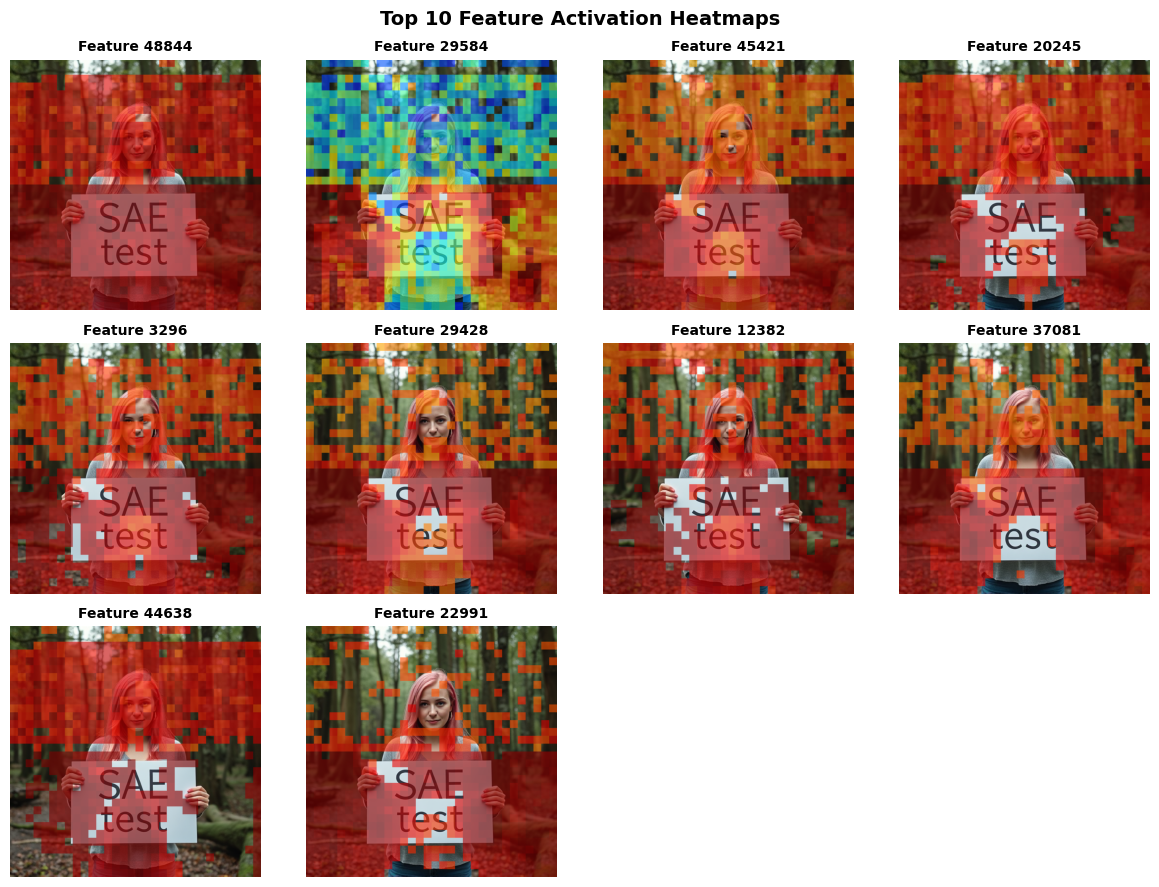

✅ Plotted heatmaps for 10 top features


In [308]:
# Plot image heatmap for all top features
print("Plotting heatmaps for top features...")

# Check if sparse_maps is 2D (no spatial dimensions) or 3D (has spatial dimensions)
is_2d_sparse_maps = len(sparse_maps.shape) == 2
if is_2d_sparse_maps:
    print(f"⚠️  Note: Sparse maps are 2D (shape: {sparse_maps.shape})")
    print("   Heatmaps will be approximate (reshaped from token sequence to spatial grid)")

# Plot all top features (no limit)
num_features_to_plot = len(top_features)
print(f"Plotting {num_features_to_plot} top features...")

# Calculate grid dimensions dynamically
# Aim for roughly square grid, but adjust based on number of features
if num_features_to_plot <= 4:
    cols = num_features_to_plot
    rows = 1
elif num_features_to_plot <= 9:
    cols = 3
    rows = (num_features_to_plot + cols - 1) // cols  # Ceiling division
elif num_features_to_plot <= 16:
    cols = 4
    rows = (num_features_to_plot + cols - 1) // cols
else:
    # For many features, use 5 columns
    cols = 5
    rows = (num_features_to_plot + cols - 1) // cols

# Adjust figure size based on number of rows
fig_height = max(4, rows * 3)
fig_width = max(12, cols * 3)

plt.figure(figsize=(fig_width, fig_height))

for i in range(num_features_to_plot):
    feature_idx = top_features[i]
    row = i // cols
    col = i % cols
    plt.subplot(rows, cols, i+1)
    
    try:
        heatmap_image = plot_image_heatmap(original_image, sparse_maps, feature_idx)
        plt.imshow(heatmap_image)
        title = f"Feature {feature_idx}"
        if is_2d_sparse_maps:
            title += "\n(approx)"
        plt.title(title, fontsize=10, fontweight='bold')
    except Exception as e:
        plt.text(0.5, 0.5, f'Error:\n{str(e)[:50]}', 
                ha='center', va='center', fontsize=8, color='red')
        plt.title(f"Feature {feature_idx}\n(Error)", fontsize=10)
    
    plt.axis("off")

plt.suptitle(f'Top {num_features_to_plot} Feature Activation Heatmaps', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Plotted heatmaps for {num_features_to_plot} top features")


[-100, -50, 50, 100]


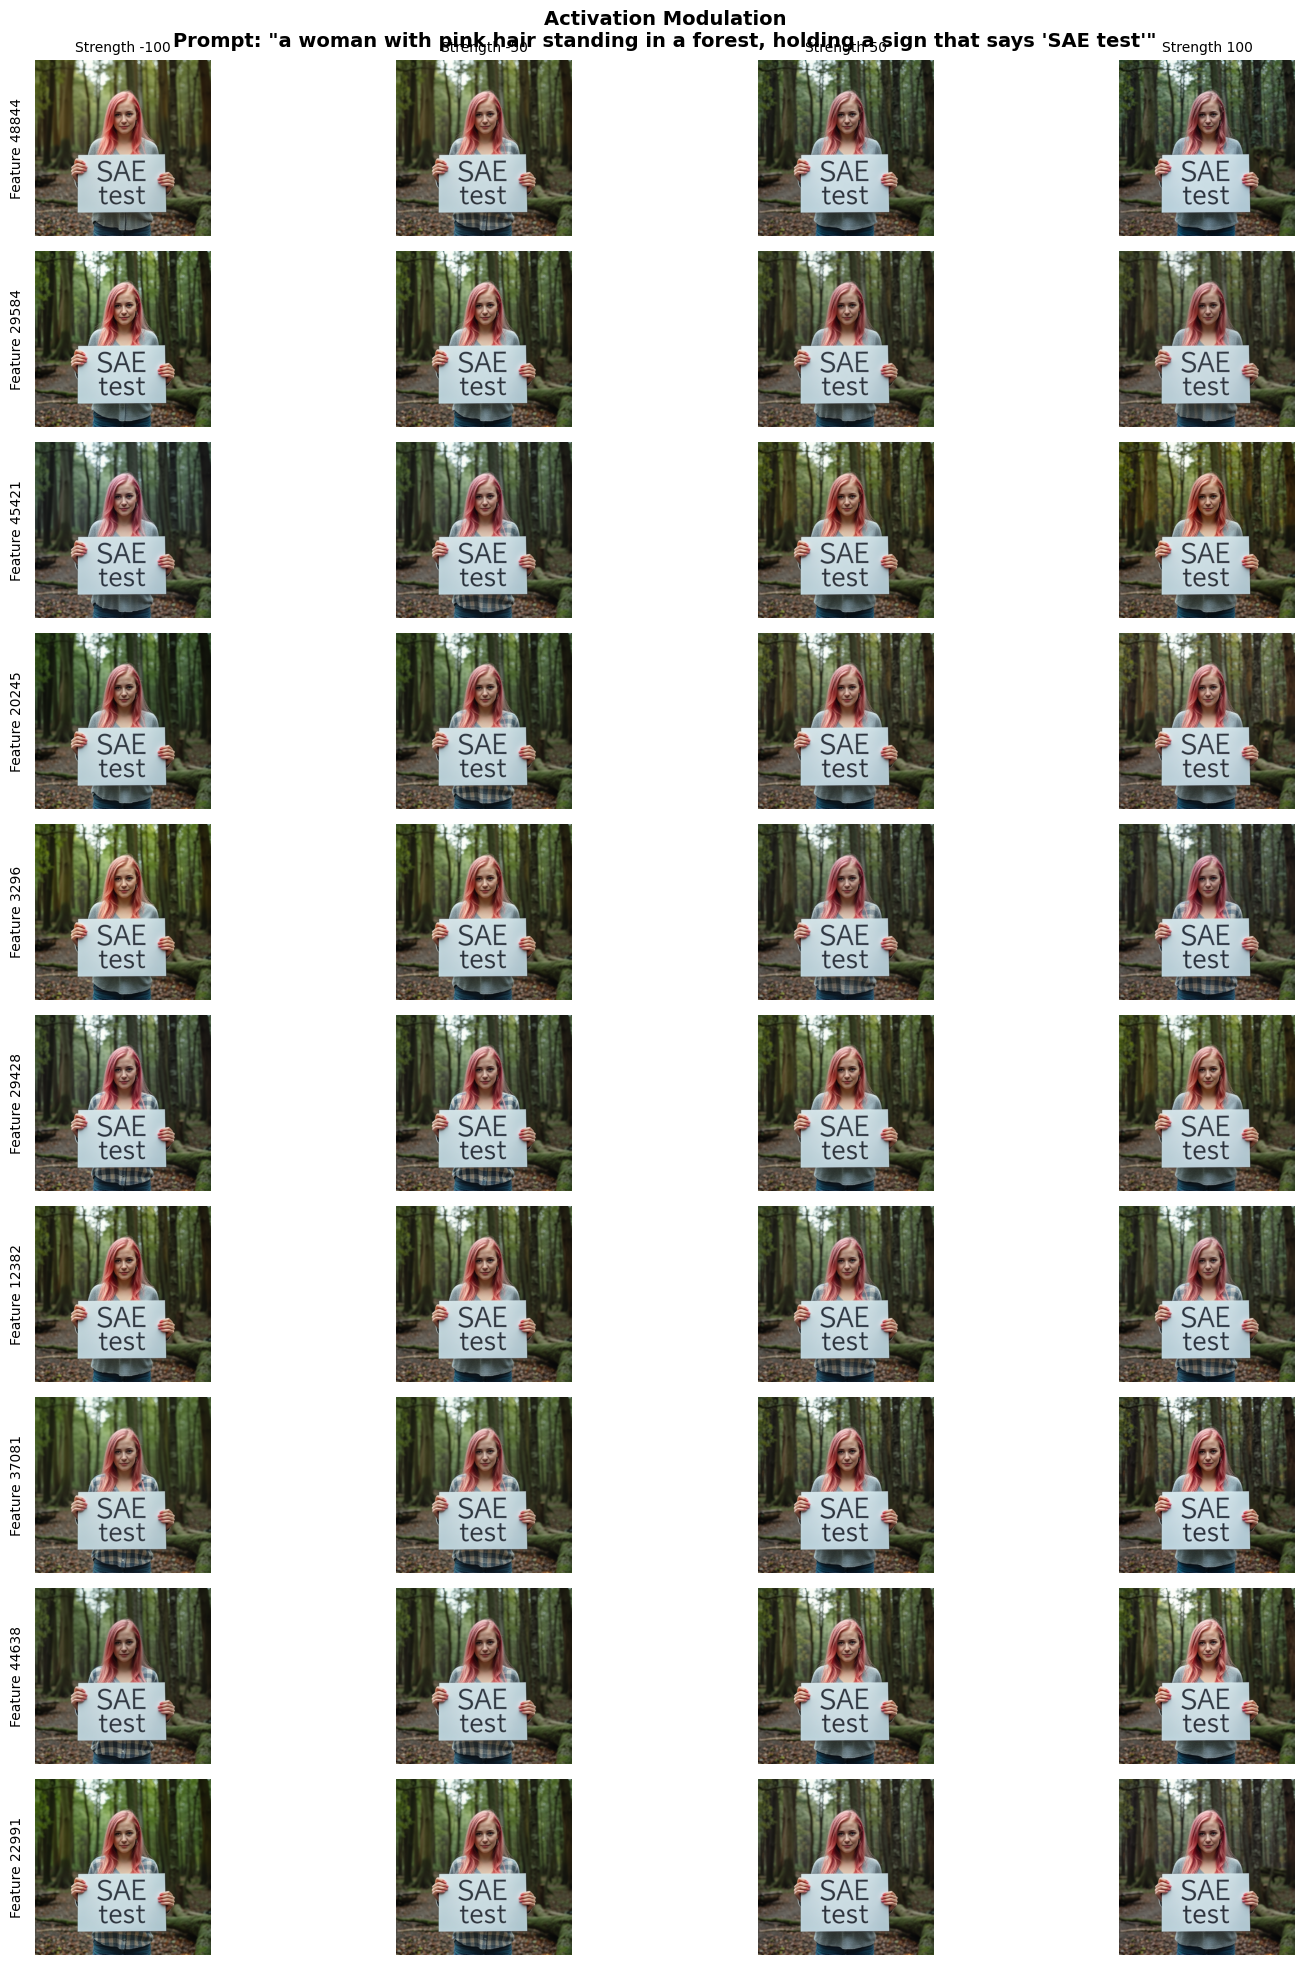

✅ Activation modulation visualization complete for 10 features


In [309]:
# Activation modulation with steering strengths -10, -5, 5, 10
def activation_modulation(code, sparse_maps, feature_idx, strength, method="spatial"):
    """
    Modulate activations using sparse maps and feature strength.
    Adapted from SDXL-turbo's activation_modulation for FLUX.
    
    IMPORTANT: This function captures the actual activation structure during generation
    and maps the sparse_maps to match that structure, ensuring spatial alignment.
    
    Args:
        code: Layer code
        sparse_maps: Sparse activation maps (h, w, num_features) or (tokens, num_features)
        feature_idx: Feature index to modulate
        strength: Strength of modulation
        method: Steering method to use:
            - "spatial" (default): Additive steering with spatial feature maps
            - "surgery": Original SAE surgery (encode-decode-modify)
            - "gytis_style": Gytis-style surgery (only modifies if feature in top-k)
            - "error_preserving": Surgery with reconstruction error preservation (CLIP-style)
            - "additive": Simple additive (no spatial maps, global strength)
    
    Returns:
        Generated PIL Image
    """
    block = code_to_block[code]
    sae = saes_dict[code]
    stream = streams_dict[code]
    
    # Extract feature map for this feature from sparse_maps
    # Store as tensor for later use in hook
    if len(sparse_maps.shape) == 3:
        # 3D: (h, w, features) - has spatial structure
        if isinstance(sparse_maps, torch.Tensor):
            feature_map_spatial = sparse_maps[:, :, feature_idx].cpu()  # (h, w)
        else:
            feature_map_spatial = torch.from_numpy(sparse_maps[:, :, feature_idx]).cpu()  # (h, w)
        sparse_h, sparse_w = feature_map_spatial.shape
        feature_map_flat_initial = None
    else:
        # 2D: (tokens, features) - no spatial structure
        if isinstance(sparse_maps, torch.Tensor):
            feature_map_flat_initial = sparse_maps[:, feature_idx].cpu()  # (tokens,)
        else:
            feature_map_flat_initial = torch.from_numpy(sparse_maps[:, feature_idx]).cpu()  # (tokens,)
        feature_map_spatial = None
        sparse_h = sparse_w = None
    
    # Create hook function that captures actual activation structure and maps feature_map correctly
    def intervention_hook(module, input, output):
        # Capture the actual output structure
        if isinstance(output, tuple):
            query, key = output
            target = query if stream == 0 else key
            other = key if stream == 0 else query
        else:
            target = output
            other = None
        
        # Determine actual spatial structure from target activations
        target_shape = target.shape
        original_shape = target_shape
        
        # Flatten for surgery methods or prepare for spatial methods
        target_flat = rearrange(target, "b ... d -> (b ...) d")
        
        # Ensure dtype/device match
        sae_dtype = next(sae.parameters()).dtype
        sae_device = next(sae.parameters()).device
        target_flat = target_flat.to(dtype=sae_dtype, device=sae_device)
        
        # Check if this is DiT (fused stream) or MMDiT (image stream only)
        is_dit_layer = code.startswith("single_transformer_blocks")
        is_mmdit_layer = code.startswith("transformer_blocks")
        
        # Handle different methods
        if method in ["surgery", "gytis_style", "error_preserving", "additive"]:
            # Surgery-based or additive methods: work on flattened activations
            # For DiT layers, we need to handle the fused stream (image + text tokens)
            
            if is_dit_layer and len(target_flat) >= 1024:
                # DiT fused stream: only apply to first 1024 tokens (image tokens)
                image_tokens = target_flat[:1024]  # First 1024: image tokens
                text_tokens = target_flat[1024:]  # Remaining: text tokens (unchanged)
                
                # Apply surgery/additive to image tokens only
                with torch.no_grad():
                    if method == "surgery":
                        image_tokens_steered = sae.surgery(image_tokens, k=feature_idx, strength=strength)
                    elif method == "gytis_style":
                        image_tokens_steered = sae.surgery_gytis_style(
                            image_tokens,
                            k=feature_idx,
                            strength=strength,
                            fallback_to_additive=True
                        )
                    elif method == "error_preserving":
                        image_tokens_steered = sae.surgery_with_error_preservation(
                            image_tokens,
                            k=feature_idx,
                            strength=strength,
                            fallback_to_additive=True
                        )
                    elif method == "additive":
                        # Simple additive: add feature direction
                        feature_direction = sae.decoder.weight[:, feature_idx]
                        image_tokens_steered = image_tokens + strength * feature_direction.unsqueeze(0)
                
                # Concatenate: [steered_image_tokens, unchanged_text_tokens]
                target_steered_flat = torch.cat([image_tokens_steered, text_tokens], dim=0)
            else:
                # MMDiT or other: apply to all tokens
                with torch.no_grad():
                    if method == "surgery":
                        target_steered_flat = sae.surgery(target_flat, k=feature_idx, strength=strength)
                    elif method == "gytis_style":
                        target_steered_flat = sae.surgery_gytis_style(
                            target_flat,
                            k=feature_idx,
                            strength=strength,
                            fallback_to_additive=True
                        )
                    elif method == "error_preserving":
                        target_steered_flat = sae.surgery_with_error_preservation(
                            target_flat,
                            k=feature_idx,
                            strength=strength,
                            fallback_to_additive=True
                        )
                    elif method == "additive":
                        # Simple additive: add feature direction
                        feature_direction = sae.decoder.weight[:, feature_idx]
                        target_steered_flat = target_flat + strength * feature_direction.unsqueeze(0)
            
            # Reshape back
            target_steered = target_steered_flat.to(dtype=target.dtype, device=target.device)
            target_reshaped = target_steered.reshape(original_shape)
            
            if isinstance(output, tuple):
                return (target_reshaped, other) if stream == 0 else (other, target_reshaped)
            else:
                return target_reshaped
        
        # For "spatial" method, continue with existing spatial mapping logic
        # (This uses add_feature_on_area with spatial feature maps)
        
        # Map feature_map to match actual activation structure
        if len(target_shape) == 5:
            # (batch, seq, height, width, dim) - MMDiT with spatial structure
            batch, seq, h, w, dim = target_shape
            
            if feature_map_spatial is not None:
                # sparse_maps is (sparse_h, sparse_w, features) - has spatial structure
                # Convert to tensor and resize to match actual (h, w) dimensions
                if isinstance(feature_map_spatial, torch.Tensor):
                    feature_map_tensor = feature_map_spatial.float().to(target.device)
                else:
                    feature_map_tensor = torch.from_numpy(feature_map_spatial).float().to(target.device)
                
                if (sparse_h, sparse_w) != (h, w):
                    # Interpolate to match actual spatial dimensions
                    feature_map_tensor = torch.nn.functional.interpolate(
                        feature_map_tensor.unsqueeze(0).unsqueeze(0),
                        size=(h, w),
                        mode='bilinear',
                        align_corners=False
                    ).squeeze(0).squeeze(0)
                
                # For 5D activations, pass spatial map (h, w) directly
                # add_feature_on_area will handle broadcasting to (batch, seq, h, w, dim)
                strength_map = feature_map_tensor * strength  # (h, w)
                return add_feature_on_area(
                    sae,
                    feature_idx,
                    strength_map,  # (h, w) spatial map
                    output,
                    stream=stream
                )
            else:
                # 2D sparse_maps - can't do proper spatial mapping, use scalar
                return add_feature_on_area(
                    sae,
                    feature_idx,
                    strength,  # Scalar strength
                    output,
                    stream=stream
                )
        elif len(target_shape) == 3:
            # (batch, seq_length, dim) - DiT or flattened MMDiT
            batch, seq_length, dim = target_shape
            
            # Check if this is DiT (fused stream) or MMDiT (image stream only)
            is_dit_layer = code.startswith("single_transformer_blocks")
            is_mmdit_layer = code.startswith("transformer_blocks")
            
            if feature_map_spatial is not None:
                # Flatten spatial feature_map (should be 32×32 = 1024 for image tokens)
                if isinstance(feature_map_spatial, torch.Tensor):
                    feature_map_flat = feature_map_spatial.flatten().to(target.device)  # (sparse_h * sparse_w,)
                else:
                    feature_map_flat = torch.from_numpy(feature_map_spatial.flatten()).to(target.device)
                
                # For DiT layers: sequence is [1024 image tokens, 512 text tokens] = 1536
                # We should ONLY apply feature map to image tokens (first 1024), not text tokens
                if is_dit_layer and seq_length >= 1024:
                    # DiT fused stream: only apply to first 1024 tokens (image tokens)
                    if len(feature_map_flat) == 1024:
                        # Perfect match: 32×32 feature map → 1024 image tokens
                        strength_map_image = feature_map_flat * strength  # (1024,)
                        # Create strength map for full sequence: [image_strength, text_zeros]
                        strength_map = torch.cat([
                            strength_map_image,  # First 1024: image tokens with feature map
                            torch.zeros(seq_length - 1024, device=target.device)  # Remaining: text tokens (no modification)
                        ])
                    else:
                        # Feature map size doesn't match 1024, pad/truncate to 1024
                        if len(feature_map_flat) < 1024:
                            padding = 1024 - len(feature_map_flat)
                            feature_map_flat = torch.cat([feature_map_flat, torch.zeros(padding, device=target.device)])
                        else:
                            feature_map_flat = feature_map_flat[:1024]
                        strength_map_image = feature_map_flat * strength
                        strength_map = torch.cat([
                            strength_map_image,
                            torch.zeros(seq_length - 1024, device=target.device)
                        ])
                else:
                    # MMDiT or other: apply to all tokens (should be 1024 for MMDiT)
                    if len(feature_map_flat) != seq_length:
                        if len(feature_map_flat) < seq_length:
                            padding = seq_length - len(feature_map_flat)
                            feature_map_flat = torch.cat([feature_map_flat, torch.zeros(padding, device=target.device)])
                        else:
                            feature_map_flat = feature_map_flat[:seq_length]
                    strength_map = feature_map_flat * strength
            elif feature_map_flat_initial is not None:
                # 2D sparse_maps - use directly
                feature_map_flat = feature_map_flat_initial.to(target.device)
                
                # For DiT layers: only apply to first 1024 tokens
                if is_dit_layer and seq_length >= 1024:
                    if len(feature_map_flat) == 1024:
                        strength_map_image = feature_map_flat * strength
                        strength_map = torch.cat([
                            strength_map_image,
                            torch.zeros(seq_length - 1024, device=target.device)
                        ])
                    else:
                        # Adjust to 1024 first
                        if len(feature_map_flat) < 1024:
                            padding = 1024 - len(feature_map_flat)
                            feature_map_flat = torch.cat([feature_map_flat, torch.zeros(padding, device=target.device)])
                        else:
                            feature_map_flat = feature_map_flat[:1024]
                        strength_map_image = feature_map_flat * strength
                        strength_map = torch.cat([
                            strength_map_image,
                            torch.zeros(seq_length - 1024, device=target.device)
                        ])
                else:
                    # MMDiT or other: apply to all tokens
                    if len(feature_map_flat) != seq_length:
                        if len(feature_map_flat) < seq_length:
                            padding = seq_length - len(feature_map_flat)
                            feature_map_flat = torch.cat([feature_map_flat, torch.zeros(padding, device=target.device)])
                        else:
                            feature_map_flat = feature_map_flat[:seq_length]
                    strength_map = feature_map_flat * strength
            else:
                # Fallback: scalar strength
                # For DiT, we might want to only apply to image tokens, but scalar applies to all
                strength_map = strength
            
            return add_feature_on_area(
                sae,
                feature_idx,
                strength_map,
                output,
                stream=stream
            )
        else:
            # Unknown shape - use scalar strength (fallback)
            return add_feature_on_area(
                sae,
                feature_idx,
                strength,
                output,
                stream=stream
            )
    
    hook_handle = pipe.transformer.get_submodule(block).register_forward_hook(intervention_hook)
    
    try:
        output = pipe(
            prompt=prompt,
            height=test_height,
            width=test_width,
            num_inference_steps=4,
            guidance_scale=3.5,
            generator=torch.Generator(device="cuda").manual_seed(42)
        )
        
        return output.images[0]
    finally:
        hook_handle.remove()

# Visualize activation modulation for top features
strengths = [-10, -5, 5, 10]
strengths = [i*10 for i in strengths]

print(strengths)

num_features_to_plot = min(10, len(top_features))

plt.figure(figsize=(16, 2*num_features_to_plot))
for i, feature_idx in enumerate(top_features[:num_features_to_plot]):
    for j, strength in enumerate(strengths):
        plt.subplot(num_features_to_plot, 4, i*4+j+1)
        plt.axis("off")
        
        try:
            # img = activation_modulation(first_code, sparse_maps, feature_idx, strength, method="surgery")
            img = activation_modulation(first_code, sparse_maps, feature_idx, strength, method="spatial")
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, f'Error:\n{str(e)[:50]}', 
                    ha='center', va='center', fontsize=8, color='red')
        
        if i == 0:
            plt.title(f"Strength {strength}", fontsize=10)
        if j == 0:
            plt.text(-0.1, 0.5, f"Feature {feature_idx}", 
                    fontsize=10, ha='center', va='center', 
                    rotation=90, transform=plt.gca().transAxes)

plt.suptitle(f'Activation Modulation\nPrompt: "{prompt}"', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Activation modulation visualization complete for {num_features_to_plot} features")


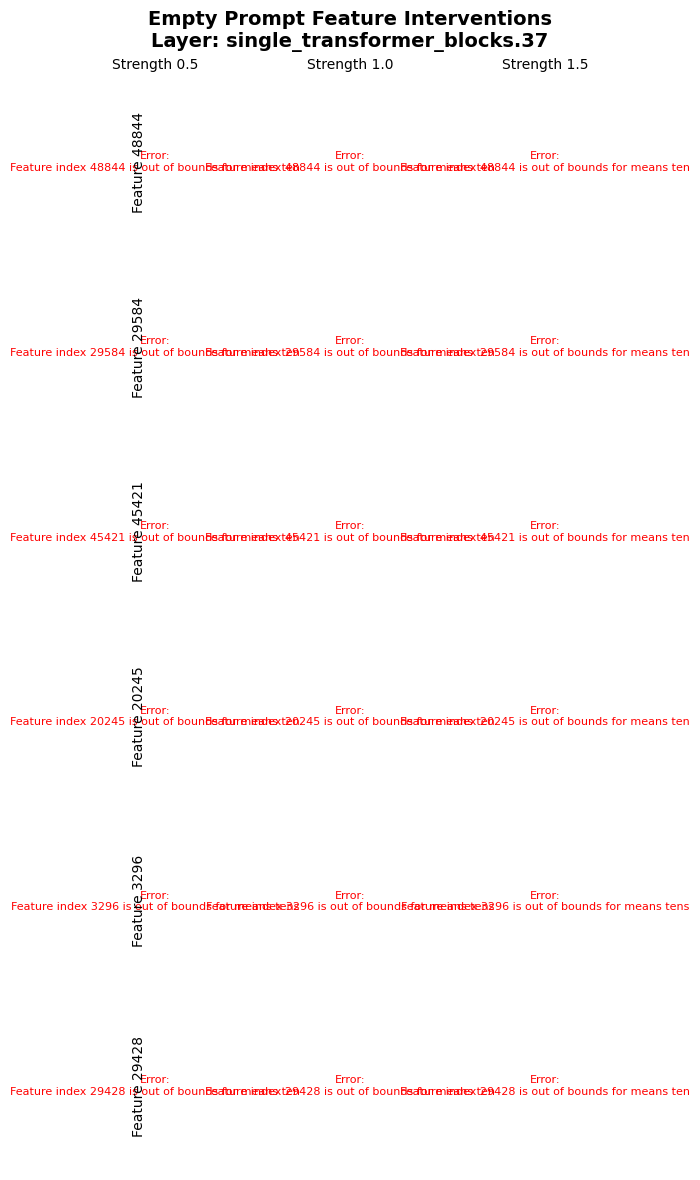

✅ Empty prompt intervention visualization complete for 6 features


In [310]:
# Empty prompt intervention
def empty_prompt_intervention(code, feature_idx, strength):
    """
    Generate image with empty prompt and feature intervention.
    Similar to SDXL-turbo's empty_prompt_intervention.
    
    Args:
        code: Layer code (e.g., "transformer_blocks.0.0")
        feature_idx: Feature index to inject
        strength: Strength of intervention
    
    Returns:
        Generated PIL Image
    """
    block = code_to_block[code]
    sae = saes_dict[code]
    stream = streams_dict[code]
    means = means_dict[code]
    
    # Validate feature_idx is within bounds
    if feature_idx < 0 or feature_idx >= sae.pages:
        raise ValueError(f"Feature index {feature_idx} is out of bounds. SAE has {sae.pages} pages (valid indices: 0-{sae.pages-1})")
    
    if feature_idx >= len(means):
        raise ValueError(f"Feature index {feature_idx} is out of bounds for means tensor. Means has {len(means)} elements (valid indices: 0-{len(means)-1}). SAE has {sae.pages} pages.")
    
    # Ensure means has the correct size (should match sae.pages)
    if len(means) != sae.pages:
        raise ValueError(f"Mismatch: means has {len(means)} elements but SAE has {sae.pages} pages. They should match.")
    
    # Create hook function that replaces with feature
    def intervention_hook(module, input, output):
        return replace_with_feature(
            sae,
            feature_idx,
            strength * means[feature_idx] * sae.k,  # Scale by mean and k (SDXL-turbo style)
            output,
            stream=stream
        )
    
    # Register hook
    hook_handle = pipe.transformer.get_submodule(block).register_forward_hook(intervention_hook)
    
    try:
        # Generate with empty prompt
        output = pipe(
            prompt="",  # Empty prompt
            height=512,
            width=512,
            num_inference_steps=4,
            guidance_scale=0.0,  # No guidance for empty prompt
            generator=torch.Generator(device="cuda").manual_seed(42)
        )
        
        return output.images[0]
    finally:
        # Always remove hook
        hook_handle.remove()

# Visualize empty prompt interventions
test_strengths = [0.5, 1.0, 1.5]
num_features_to_plot = min(6, len(top_features))

plt.figure(figsize=(6, 12))
for i, feature_idx in enumerate(top_features[:num_features_to_plot]):
    for j, strength in enumerate(test_strengths):
        plt.subplot(num_features_to_plot, 3, i*3+j+1)
        
        try:
            img = empty_prompt_intervention(first_code, feature_idx, strength)
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, f'Error:\n{str(e)[:50]}', 
                    ha='center', va='center', fontsize=8, color='red')
        
        plt.axis("off")
        
        if i == 0:
            plt.title(f"Strength {strength}", fontsize=10)
        if j == 0:
            plt.text(-0.1, 0.5, f"Feature {feature_idx}", 
                    fontsize=10, ha='center', va='center', 
                    rotation=90, transform=plt.gca().transAxes)

plt.suptitle(f'Empty Prompt Feature Interventions\nLayer: {first_code}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Empty prompt intervention visualization complete for {num_features_to_plot} features")
